# Problem 2: IBM Quantum Hardware Setup

This notebook starts with the runtime, backend, simulator, and Sampler settings needed to run circuits on IBM Quantum hardware in the same style as `dynamic_cnot_qem_mthree.ipynb`.


In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import IfElseOp
from qiskit.circuit.classical import expr
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_circuit_layout
from qiskit_ibm_runtime import QiskitRuntimeService, Batch, SamplerV2 as Sampler
from qiskit_aer import AerSimulator

import matplotlib.pyplot as plt
import numpy as np
import mthree

## Credentials

Recommended workflow: save your IBM Quantum credentials once, then load them by account name in later cells. Do not commit a notebook containing a real API key.


In [ ]:
import os

ACCOUNT_NAME = "QHackathon"

IBM_QUANTUM_TOKEN = os.getenv("IBM_QUANTUM_TOKEN")
IBM_QUANTUM_INSTANCE = os.getenv("IBM_QUANTUM_INSTANCE")

# Set this to True only when you want to save or overwrite local credentials.
SAVE_ACCOUNT = False

if SAVE_ACCOUNT:
    if not IBM_QUANTUM_TOKEN:
        raise ValueError("Set IBM_QUANTUM_TOKEN before saving the account.")

    QiskitRuntimeService.save_account(
        token=IBM_QUANTUM_TOKEN,
        instance=IBM_QUANTUM_INSTANCE or None,
        name=ACCOUNT_NAME,
        set_as_default=True,
        overwrite=True,
    )
    print(f"Saved IBM Quantum account as {ACCOUNT_NAME!r}.")


In [ ]:
# Hardware/simulator switch.
USE_REAL_HARDWARE = True

# Leave as None to use least_busy. Set to a backend name if the hackathon assigns one.
# Example: PREFERRED_BACKEND_NAME = "ibm_yonsei"
PREFERRED_BACKEND_NAME = None
MIN_NUM_QUBITS = 127

# If ACCOUNT_NAME has been saved, this mirrors the reference notebook.
# Otherwise, QiskitRuntimeService() will try the default saved account.
try:
    service = QiskitRuntimeService(name=ACCOUNT_NAME)
except Exception:
    service = QiskitRuntimeService()

if PREFERRED_BACKEND_NAME:
    backend = service.backend(PREFERRED_BACKEND_NAME)
else:
    backend = service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=MIN_NUM_QUBITS,
    )

backend_name = backend.name if isinstance(backend.name, str) else backend.name()
print("Selected backend:", backend_name)
print("Active instance:", service.active_instance())

# Some dynamic-circuit examples need if_else in the target before transpilation.
if "if_else" not in backend.target.operation_names:
    backend.target.add_instruction(IfElseOp, name="if_else")

# A local noisy simulator derived from the selected hardware calibration.
backend_sim = AerSimulator.from_backend(backend)
execution_backend = backend if USE_REAL_HARDWARE else backend_sim
print(f"Execution backend: {execution_backend} (USE_REAL_HARDWARE={USE_REAL_HARDWARE})")


In [4]:
def configure_sampler_qem(sampler):
    """Configure SamplerV2 options used by the reference notebook."""
    sampler.options.twirling.enable_gates = True
    sampler.options.twirling.enable_measure = True
    sampler.options.twirling.strategy = "active-accum"
    sampler.options.twirling.num_randomizations = "auto"
    sampler.options.twirling.shots_per_randomization = "auto"

    # Dynamical decoupling is incompatible with dynamic circuits that contain
    # mid-circuit measurements and feed-forward control.
    sampler.options.dynamical_decoupling.enable = False
    return sampler


In [5]:
# Optional smoke test. Keep False until you are ready to spend QPU time.
RUN_SMOKE_TEST = False

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_qc = pm.run(qc)

if RUN_SMOKE_TEST:
    sampler = configure_sampler_qem(Sampler(mode=execution_backend))
    job = sampler.run([isa_qc], shots=256)
    result = job.result()
    print(result[0].data.c.get_counts())
else:
    print("Smoke-test circuit is ready. Set RUN_SMOKE_TEST=True to submit it.")


Smoke-test circuit is ready. Set RUN_SMOKE_TEST=True to submit it.


## Problem 2.1: Hardware Topology Inspection

`inspect_hardware()` takes an IBM backend name, visualizes its connectivity, summarizes hardware metadata, and returns connectivity/error tables that we can reuse for hardware-aware long-range CNOT design.


In [3]:
from collections import Counter
import math

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    from qiskit.visualization import plot_gate_map, plot_error_map
except Exception:
    plot_gate_map = None
    plot_error_map = None


def _backend_name(backend_obj):
    name = getattr(backend_obj, "name", None)
    return name() if callable(name) else name


def _backend_num_qubits(backend_obj):
    num_qubits = getattr(backend_obj, "num_qubits", None)
    if num_qubits is not None:
        return int(num_qubits)
    try:
        return int(backend_obj.configuration().n_qubits)
    except Exception:
        return None


def _target_operation_names(backend_obj):
    target = getattr(backend_obj, "target", None)
    if target is not None:
        return sorted(str(name) for name in target.operation_names)
    try:
        return sorted(backend_obj.configuration().basis_gates)
    except Exception:
        return []


def _target_instruction_rows(backend_obj):
    """Extract instruction properties from BackendV2 Target data."""
    target = getattr(backend_obj, "target", None)
    if target is None:
        return []

    rows = []
    for op_name in sorted(target.operation_names):
        try:
            instruction_properties = target[op_name]
        except Exception:
            continue
        if not hasattr(instruction_properties, "items"):
            continue

        for qargs, props in instruction_properties.items():
            if qargs is None:
                continue
            qargs = tuple(int(q) for q in qargs)
            error = getattr(props, "error", None) if props is not None else None
            duration = getattr(props, "duration", None) if props is not None else None
            rows.append(
                {
                    "operation": str(op_name),
                    "qargs": qargs,
                    "n_qubits": len(qargs),
                    "error": error,
                    "duration_s": duration,
                    "duration_us": None if duration is None else duration * 1e6,
                }
            )
    return rows


def _coupling_edges(backend_obj, instruction_rows=None):
    cmap = getattr(backend_obj, "coupling_map", None)
    if callable(cmap):
        cmap = cmap()
    if cmap is not None:
        try:
            return [tuple(int(q) for q in edge) for edge in cmap.get_edges()]
        except Exception:
            try:
                return [tuple(int(q) for q in edge) for edge in cmap]
            except Exception:
                pass

    if instruction_rows is None:
        instruction_rows = _target_instruction_rows(backend_obj)
    return sorted({row["qargs"] for row in instruction_rows if row["n_qubits"] == 2})


def _qubit_property_rows(backend_obj):
    try:
        props = backend_obj.properties()
    except Exception:
        return []

    num_qubits = _backend_num_qubits(backend_obj)
    if num_qubits is None:
        return []

    def safe_call(method_name, *args):
        method = getattr(props, method_name, None)
        if method is None:
            return None
        try:
            return method(*args)
        except Exception:
            return None

    rows = []
    for q in range(num_qubits):
        t1 = safe_call("t1", q)
        t2 = safe_call("t2", q)
        rows.append(
            {
                "qubit": q,
                "T1_us": None if t1 is None else t1 * 1e6,
                "T2_us": None if t2 is None else t2 * 1e6,
                "frequency_GHz": safe_call("frequency", q),
                "readout_error": safe_call("readout_error", q),
            }
        )
    return rows


def _connectivity_summary(edges, num_qubits):
    undirected_edges = {tuple(sorted(edge)) for edge in edges if len(edge) == 2}
    degree = [0] * num_qubits if num_qubits is not None else []
    for u, v in undirected_edges:
        if num_qubits is not None and u < num_qubits and v < num_qubits:
            degree[u] += 1
            degree[v] += 1

    summary = {
        "directed_edges": len(edges),
        "undirected_edges": len(undirected_edges),
        "avg_degree": float(np.mean(degree)) if degree else None,
        "max_degree": max(degree) if degree else None,
        "isolated_qubits": [q for q, d in enumerate(degree) if d == 0],
    }

    try:
        import networkx as nx

        graph = nx.Graph()
        graph.add_nodes_from(range(num_qubits))
        graph.add_edges_from(undirected_edges)
        components = sorted((len(c) for c in nx.connected_components(graph)), reverse=True)
        summary["connected_components"] = len(components)
        summary["largest_component_size"] = components[0] if components else 0
    except Exception:
        summary["connected_components"] = None
        summary["largest_component_size"] = None

    return summary


def _print_numeric_summary(label, rows, key):
    values = []
    for row in rows:
        value = row.get(key)
        if isinstance(value, (int, float)) and not math.isnan(value):
            values.append(value)
    if not values:
        print(f"{label}: no numeric {key} values found")
        return

    arr = np.asarray(values, dtype=float)
    print(
        f"{label}: count={len(arr)}, min={arr.min():.4g}, "
        f"median={np.median(arr):.4g}, mean={arr.mean():.4g}, max={arr.max():.4g}"
    )


def _display_rows(title, rows, columns=None, sort_by=None, ascending=True, max_rows=12):
    print(f"\n{title}")
    if not rows:
        print("  No rows available.")
        return None

    if pd is not None:
        df = pd.DataFrame(rows)
        if sort_by is not None and sort_by in df.columns:
            df = df.sort_values(sort_by, ascending=ascending, na_position="last")
        if columns is not None:
            df = df[[col for col in columns if col in df.columns]]
        display(df.head(max_rows))
        return df

    for row in rows[:max_rows]:
        print(row)
    return rows


def _plot_backend_topology(backend_obj, edges, num_qubits, title, seed=7):
    if plot_gate_map is not None:
        try:
            fig = plot_gate_map(backend_obj, plot_directed=True)
            if getattr(fig, "axes", None):
                fig.axes[0].set_title(title)
            display(fig)
            plt.close(fig)
            return fig
        except Exception as exc:
            print(f"plot_gate_map fallback triggered: {exc}")

    try:
        import networkx as nx

        graph = nx.DiGraph()
        graph.add_nodes_from(range(num_qubits))
        graph.add_edges_from(edges)
        pos = nx.spring_layout(graph.to_undirected(), seed=seed, iterations=120)

        fig, ax = plt.subplots(figsize=(9, 7))
        node_size = 180 if num_qubits <= 35 else 60 if num_qubits <= 90 else 30
        nx.draw_networkx_nodes(graph, pos, node_size=node_size, node_color="#f7f7f7", edgecolors="#333333", ax=ax)
        nx.draw_networkx_edges(graph, pos, width=0.8, alpha=0.55, arrows=False, ax=ax)
        if num_qubits <= 80:
            nx.draw_networkx_labels(graph, pos, font_size=7, ax=ax)
        ax.set_title(title)
        ax.set_axis_off()
        plt.tight_layout()
        display(fig)
        plt.close(fig)
        return fig
    except Exception as exc:
        print(f"Could not draw fallback topology graph: {exc}")
        return None


def inspect_hardware(hardware_name=None, runtime_service=None, draw=True, show_error_map=False, max_rows=12):
    """Inspect an IBM Quantum backend for Problem 2.1.

    Args:
        hardware_name: Backend name such as "ibm_brisbane". If None, uses the global `backend`.
            You can also pass an already-loaded backend object.
        runtime_service: Optional QiskitRuntimeService. If omitted, uses the global `service`.
        draw: Whether to visualize the coupling topology.
        show_error_map: Whether to try Qiskit's full error-map visualization.
        max_rows: Number of table rows to display per section.

    Returns:
        dict containing the backend, coupling edges, graph summary, and calibration tables.
    """
    if hasattr(hardware_name, "target"):
        backend_obj = hardware_name
    elif hardware_name is None:
        backend_obj = globals().get("backend")
        if backend_obj is None:
            raise ValueError("No hardware_name was provided and global `backend` is not defined.")
    else:
        runtime_service = runtime_service or globals().get("service")
        if runtime_service is None:
            raise ValueError("Provide runtime_service or run the QiskitRuntimeService setup cell first.")
        backend_obj = runtime_service.backend(hardware_name)

    name = _backend_name(backend_obj)
    num_qubits = _backend_num_qubits(backend_obj)
    operation_names = _target_operation_names(backend_obj)
    instruction_rows = _target_instruction_rows(backend_obj)
    edges = _coupling_edges(backend_obj, instruction_rows)
    summary = _connectivity_summary(edges, num_qubits)

    try:
        status = backend_obj.status()
        status_info = {
            "operational": getattr(status, "operational", None),
            "pending_jobs": getattr(status, "pending_jobs", None),
            "status_msg": getattr(status, "status_msg", None),
        }
    except Exception:
        status_info = {}

    try:
        properties = backend_obj.properties()
        last_update = getattr(properties, "last_update_date", None)
    except Exception:
        last_update = None

    print(f"Backend: {name}")
    print(f"Qubits: {num_qubits}")
    if status_info:
        print(f"Status: {status_info}")
    if last_update is not None:
        print(f"Calibration timestamp: {last_update}")
    print("Operations:", ", ".join(operation_names[:30]) + (" ..." if len(operation_names) > 30 else ""))
    print("Connectivity summary:", summary)

    if draw:
        _plot_backend_topology(backend_obj, edges, num_qubits, f"{name} coupling topology")

    if show_error_map and plot_error_map is not None:
        try:
            fig = plot_error_map(backend_obj)
            display(fig)
            plt.close(fig)
        except Exception as exc:
            print(f"Could not draw full error map: {exc}")

    twoq_rows = [row for row in instruction_rows if row["n_qubits"] == 2 and row["error"] is not None]
    oneq_rows = [
        row for row in instruction_rows
        if row["n_qubits"] == 1 and row["operation"] != "measure" and row["error"] is not None
    ]
    measure_rows = [row for row in instruction_rows if row["operation"] == "measure"]
    qubit_rows = _qubit_property_rows(backend_obj)

    print("\nError summaries")
    _print_numeric_summary("Two-qubit operation errors", twoq_rows, "error")
    _print_numeric_summary("One-qubit operation errors", oneq_rows, "error")
    _print_numeric_summary("Measurement errors", measure_rows, "error")
    _print_numeric_summary("Readout errors from properties", qubit_rows, "readout_error")

    twoq_df = _display_rows(
        "Lowest-error two-qubit operations",
        twoq_rows,
        columns=["operation", "qargs", "error", "duration_us"],
        sort_by="error",
        ascending=True,
        max_rows=max_rows,
    )
    _display_rows(
        "Highest-error two-qubit operations",
        twoq_rows,
        columns=["operation", "qargs", "error", "duration_us"],
        sort_by="error",
        ascending=False,
        max_rows=max_rows,
    )
    measure_df = _display_rows(
        "Measurement/readout operations",
        measure_rows,
        columns=["operation", "qargs", "error", "duration_us"],
        sort_by="error",
        ascending=True,
        max_rows=max_rows,
    )
    qubit_df = _display_rows(
        "Qubit coherence and readout properties",
        qubit_rows,
        columns=["qubit", "T1_us", "T2_us", "frequency_GHz", "readout_error"],
        sort_by="readout_error",
        ascending=True,
        max_rows=max_rows,
    )

    try:
        import networkx as nx

        connectivity_graph = nx.DiGraph()
        connectivity_graph.add_nodes_from(range(num_qubits))
        connectivity_graph.add_edges_from(edges)
    except Exception:
        connectivity_graph = None

    return {
        "backend": backend_obj,
        "backend_name": name,
        "num_qubits": num_qubits,
        "operation_names": operation_names,
        "coupling_edges": edges,
        "connectivity_graph": connectivity_graph,
        "connectivity_summary": summary,
        "status": status_info,
        "instruction_rows": instruction_rows,
        "two_qubit_rows": twoq_rows,
        "one_qubit_rows": oneq_rows,
        "measure_rows": measure_rows,
        "qubit_rows": qubit_rows,
        "two_qubit_df": twoq_df,
        "measure_df": measure_df,
        "qubit_df": qubit_df,
    }


In [ ]:
# Example usage for the selected Fez backend:
# hardware_info = inspect_hardware(backend, draw=True, show_error_map=False, max_rows=10)

# Example usage by backend name:
hardware_info = inspect_hardware("ibm_fez", draw=True, show_error_map=True, max_rows=10)

# The returned data will be useful for choosing low-error ancilla bus paths:
hardware_info["coupling_edges"][:5]
hardware_info["two_qubit_df"].head()


## Problem 2.1: Shortest Bus Route

For the first hardware-aware routing step, we use an unweighted BFS shortest path on the hardware connectivity graph. The returned path is interpreted as: endpoint qubits are system qubits, and interior path qubits are sacrificial ancilla bus qubits.


In [4]:
from collections import deque


def _extract_coupling_edges(hardware=None, edges=None):
    """Return directed coupling edges from raw edges, hardware_info, or a backend."""
    if edges is not None:
        return [tuple(map(int, edge)) for edge in edges]

    if hardware is None:
        hardware = globals().get("hardware_info", None) or globals().get("backend", None)
    if hardware is None:
        raise ValueError("Provide `hardware`, `edges`, or define global `hardware_info`/`backend`.")

    if isinstance(hardware, dict):
        if "coupling_edges" not in hardware:
            raise ValueError("hardware_info dictionary must contain `coupling_edges`.")
        return [tuple(map(int, edge)) for edge in hardware["coupling_edges"]]

    coupling_map = getattr(hardware, "coupling_map", None)
    if callable(coupling_map):
        coupling_map = coupling_map()
    if coupling_map is not None:
        try:
            return [tuple(map(int, edge)) for edge in coupling_map.get_edges()]
        except Exception:
            return [tuple(map(int, edge)) for edge in coupling_map]

    target = getattr(hardware, "target", None)
    if target is not None:
        target_edges = set()
        for instruction_name in target.operation_names:
            for qargs in target[instruction_name]:
                if qargs is not None and len(qargs) == 2:
                    target_edges.add(tuple(map(int, qargs)))
        if target_edges:
            return sorted(target_edges)

    raise ValueError("Could not extract coupling edges from the provided hardware object.")


def _build_adjacency(edges, directed=False, blocked_qubits=None):
    blocked = set(map(int, blocked_qubits or []))
    adjacency = {}
    for edge in edges:
        if len(edge) != 2:
            continue
        u, v = map(int, edge)
        if u in blocked or v in blocked:
            continue
        adjacency.setdefault(u, set()).add(v)
        adjacency.setdefault(v, set())
        if not directed:
            adjacency[v].add(u)
    return {node: sorted(neighbors) for node, neighbors in adjacency.items()}


def bfs_shortest_path(control_qubit, target_qubit, hardware=None, edges=None, directed=False, blocked_qubits=None):
    """Find the shortest connectivity path between two physical qubits using BFS."""
    control_qubit = int(control_qubit)
    target_qubit = int(target_qubit)
    if control_qubit == target_qubit:
        raise ValueError("control_qubit and target_qubit must be distinct.")

    blocked = set(map(int, blocked_qubits or []))
    if control_qubit in blocked or target_qubit in blocked:
        raise ValueError("Endpoints cannot be listed in blocked_qubits.")

    coupling_edges = _extract_coupling_edges(hardware=hardware, edges=edges)
    adjacency = _build_adjacency(coupling_edges, directed=directed, blocked_qubits=blocked)

    queue = deque([(control_qubit, [control_qubit])])
    visited = {control_qubit}

    while queue:
        node, path = queue.popleft()
        for neighbor in adjacency.get(node, []):
            if neighbor in visited:
                continue
            next_path = path + [neighbor]
            if neighbor == target_qubit:
                return next_path
            visited.add(neighbor)
            queue.append((neighbor, next_path))

    direction = "directed" if directed else "undirected"
    raise ValueError(f"No {direction} path found from {control_qubit} to {target_qubit}.")


def find_cnot_route(control_qubit, target_qubit, hardware=None, edges=None, directed=False, blocked_qubits=None):
    """Return the shortest physical route for a long-range CNOT bus.

    The path endpoints are the logical/system qubits. The interior nodes are
    sacrificial ancilla bus qubits for the dynamic long-range CNOT protocol.
    """
    path = bfs_shortest_path(
        control_qubit,
        target_qubit,
        hardware=hardware,
        edges=edges,
        directed=directed,
        blocked_qubits=blocked_qubits,
    )
    intermediate_qubits = path[1:-1]
    return {
        "control_qubit": path[0],
        "target_qubit": path[-1],
        "path": path,
        "route_string": " -> ".join(map(str, path)),
        "num_edges": len(path) - 1,
        "num_intermediate_qubits": len(intermediate_qubits),
        "system_qubits": (path[0], path[-1]),
        "ancilla_bus_qubits": intermediate_qubits,
        "directed": directed,
        "blocked_qubits": sorted(map(int, blocked_qubits or [])),
    }


def _draw_cnot_route(route, hardware=None, edges=None, directed=False, seed=7):
    """Visualize a route over the hardware graph, highlighting the bus path."""
    path = list(map(int, route["path"]))
    route_nodes = set(path)
    route_edges = {tuple(sorted(edge)) for edge in zip(path[:-1], path[1:])}

    if hardware is None and edges is None:
        hardware = globals().get("hardware_info", None)

    backend_obj = None
    if isinstance(hardware, dict):
        backend_obj = hardware.get("backend")
    elif hardware is not None and hasattr(hardware, "coupling_map"):
        backend_obj = hardware

    if backend_obj is not None and plot_gate_map is not None:
        try:
            num_qubits = _backend_num_qubits(backend_obj)
            coupling_edges = [tuple(map(int, edge)) for edge in backend_obj.coupling_map.get_edges()]
            qubit_color = ["#d8d8d8"] * num_qubits
            for qubit in route["ancilla_bus_qubits"]:
                qubit_color[qubit] = "#ffbf00"
            qubit_color[route["control_qubit"]] = "#2ca02c"
            qubit_color[route["target_qubit"]] = "#d62728"
            line_color = [
                "#d62728" if tuple(sorted(edge)) in route_edges else "#d0d0d0"
                for edge in coupling_edges
            ]
            fig = plot_gate_map(
                backend_obj,
                figsize=(14, 12),
                plot_directed=False,
                qubit_color=qubit_color,
                line_color=line_color,
                line_width=3,
                font_color="#111111",
            )
            if getattr(fig, "axes", None):
                fig.axes[0].set_title(
                    f"Shortest CNOT bus route: {route['control_qubit']} -> {route['target_qubit']} "
                    f"({route['num_edges']} edges)"
                )
            display(fig)
            plt.close(fig)
            return fig
        except Exception as exc:
            print(f"plot_gate_map route overlay failed; using fallback layout: {exc}")

    try:
        import networkx as nx
    except ImportError:
        print("Install networkx to draw route visualizations.")
        return None

    try:
        coupling_edges = _extract_coupling_edges(hardware=hardware, edges=edges)
    except Exception:
        coupling_edges = list(zip(path[:-1], path[1:]))

    graph = nx.DiGraph() if directed else nx.Graph()
    graph.add_edges_from(coupling_edges)
    graph.add_nodes_from(path)

    layout_graph = graph.to_undirected() if directed else graph
    try:
        pos = nx.nx_pydot.graphviz_layout(layout_graph, prog="neato")
    except Exception:
        pos = nx.spring_layout(layout_graph, seed=seed, iterations=160)

    fig, ax = plt.subplots(figsize=(10, 7))
    nx.draw_networkx_edges(layout_graph, pos, edge_color="#d0d0d0", width=0.8, alpha=0.55, ax=ax)

    highlighted_edges = [edge for edge in layout_graph.edges() if tuple(sorted(edge)) in route_edges]
    nx.draw_networkx_edges(layout_graph, pos, edgelist=highlighted_edges, edge_color="#d62728", width=3.0, ax=ax)

    other_nodes = [node for node in layout_graph.nodes if node not in route_nodes]
    ancilla_nodes = route["ancilla_bus_qubits"]
    control_node = route["control_qubit"]
    target_node = route["target_qubit"]

    nx.draw_networkx_nodes(layout_graph, pos, nodelist=other_nodes, node_size=35, node_color="#eeeeee", edgecolors="#bbbbbb", linewidths=0.4, ax=ax)
    nx.draw_networkx_nodes(layout_graph, pos, nodelist=ancilla_nodes, node_size=140, node_color="#ffbf00", edgecolors="#7a4f00", linewidths=0.8, ax=ax)
    nx.draw_networkx_nodes(layout_graph, pos, nodelist=[control_node], node_size=210, node_color="#2ca02c", edgecolors="#0b4f0b", linewidths=1.0, ax=ax)
    nx.draw_networkx_nodes(layout_graph, pos, nodelist=[target_node], node_size=210, node_color="#d62728", edgecolors="#6b1111", linewidths=1.0, ax=ax)

    label_nodes = set(path)
    labels = {node: str(node) for node in label_nodes}
    nx.draw_networkx_labels(layout_graph, pos, labels=labels, font_size=8, font_color="#111111", ax=ax)

    ax.set_title(f"Shortest CNOT bus route: {control_node} -> {target_node} ({route['num_edges']} edges)")
    ax.set_axis_off()
    plt.tight_layout()
    display(fig)
    plt.close(fig)
    return fig


def print_cnot_route(route, hardware=None, edges=None, draw=True):
    print(f"Control qubit: {route['control_qubit']}")
    print(f"Target qubit:  {route['target_qubit']}")
    print(f"Route:         {route['route_string']}")
    print(f"Edges:         {route['num_edges']}")
    print(f"Intermediate n: {route['num_intermediate_qubits']}")
    print(f"Ancilla bus:   {route['ancilla_bus_qubits']}")
    if draw:
        _draw_cnot_route(route, hardware=hardware, edges=edges, directed=route.get("directed", False))


Control qubit: 0
Target qubit:  155
Route:         0 -> 1 -> 2 -> 3 -> 16 -> 23 -> 24 -> 25 -> 37 -> 45 -> 46 -> 47 -> 57 -> 67 -> 68 -> 69 -> 78 -> 89 -> 90 -> 91 -> 98 -> 111 -> 112 -> 113 -> 119 -> 133 -> 134 -> 135 -> 139 -> 155
Edges:         29
Intermediate n: 28
Ancilla bus:   [1, 2, 3, 16, 23, 24, 25, 37, 45, 46, 47, 57, 67, 68, 69, 78, 89, 90, 91, 98, 111, 112, 113, 119, 133, 134, 135, 139]


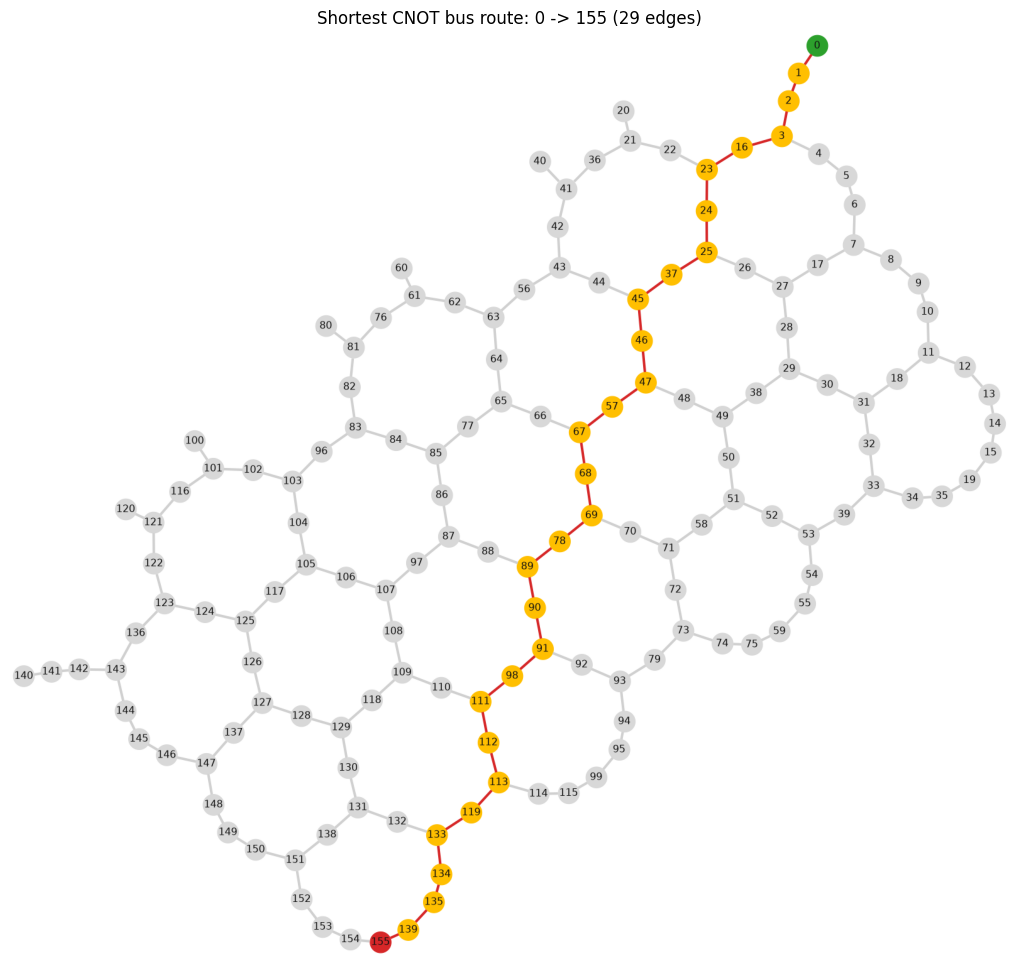

{'control_qubit': 0,
 'target_qubit': 155,
 'path': [0,
  1,
  2,
  3,
  16,
  23,
  24,
  25,
  37,
  45,
  46,
  47,
  57,
  67,
  68,
  69,
  78,
  89,
  90,
  91,
  98,
  111,
  112,
  113,
  119,
  133,
  134,
  135,
  139,
  155],
 'route_string': '0 -> 1 -> 2 -> 3 -> 16 -> 23 -> 24 -> 25 -> 37 -> 45 -> 46 -> 47 -> 57 -> 67 -> 68 -> 69 -> 78 -> 89 -> 90 -> 91 -> 98 -> 111 -> 112 -> 113 -> 119 -> 133 -> 134 -> 135 -> 139 -> 155',
 'num_edges': 29,
 'num_intermediate_qubits': 28,
 'system_qubits': (0, 155),
 'ancilla_bus_qubits': [1,
  2,
  3,
  16,
  23,
  24,
  25,
  37,
  45,
  46,
  47,
  57,
  67,
  68,
  69,
  78,
  89,
  90,
  91,
  98,
  111,
  112,
  113,
  119,
  133,
  134,
  135,
  139],
 'directed': False,
 'blocked_qubits': []}

In [9]:
# Example: shortest undirected ancilla-bus route on the inspected IBM backend.
route_example = find_cnot_route(0, 155, hardware=hardware_info, directed=False)
print_cnot_route(route_example, hardware=hardware_info)
route_example


## Appendix B: Unitary Long-Range CNOT Baselines

The following constructors implement the four unitary strategies from Appendix B. Circuits are built on a local 1D chain of length `distance + 2`. For Ia/Ib/Ic, interior qubits are ancillas initialized in `|0>` and returned to `|0>`. Strategy II treats all chain qubits as system qubits and does not swap logical qubits back.


In [5]:
def _validate_distance(distance):
    if distance is None:
        raise ValueError("Provide `distance`.")
    distance = int(distance)
    if distance < 0:
        raise ValueError("distance must be non-negative.")
    return distance


def _new_unitary_cnot_circuit(strategy, distance):
    distance = _validate_distance(distance)
    qr = QuantumRegister(distance + 2, "q")
    qc = QuantumCircuit(qr, name=f"CNOT_{strategy}")
    qc.metadata = {
        "unitary_strategy": strategy,
        "distance": distance,
        "control_index": 0,
        "target_index": distance + 1,
    }
    return qc, distance


def _move_state_right(qc, left, right):
    """Move an unknown state from `left` into a right-neighbor `|0>` qubit."""
    qc.cx(left, right)
    qc.cx(right, left)


def _move_state_left(qc, right, left):
    """Move an unknown state from `right` into a left-neighbor `|0>` qubit."""
    qc.cx(right, left)
    qc.cx(left, right)


def _swap_via_cx(qc, a, b):
    qc.cx(a, b)
    qc.cx(b, a)
    qc.cx(a, b)


def unitary_cnot_Ia(distance, add_barriers=True):
    """Strategy Ia: copy control across the bus, act on target, then uncompute."""
    qc, n = _new_unitary_cnot_circuit("Ia", distance=distance)
    for i in range(n + 1):
        qc.cx(i, i + 1)
    if add_barriers:
        qc.barrier()
    for i in range(n - 1, -1, -1):
        qc.cx(i, i + 1)
    return qc


def unitary_cnot_Ib(distance, split=None, add_barriers=True):
    """Strategy Ib: copy control part-way, move target part-way, then undo.

    For even n and split=n/2, this has 3n + 1 CNOTs. For odd n, the
    midpoint is ambiguous; the default split=floor(n/2) assigns the extra
    edge to the target-moving side.
    """
    qc, n = _new_unitary_cnot_circuit("Ib", distance=distance)
    split = n // 2 if split is None else int(split)
    if split < 0 or split > n:
        raise ValueError("split must satisfy 0 <= split <= distance.")

    for i in range(split):
        qc.cx(i, i + 1)

    for right in range(n + 1, split + 1, -1):
        _move_state_left(qc, right, right - 1)

    if add_barriers:
        qc.barrier()
    qc.cx(split, split + 1)
    if add_barriers:
        qc.barrier()

    for left in range(split + 1, n + 1):
        _move_state_right(qc, left, left + 1)

    for i in range(split - 1, -1, -1):
        qc.cx(i, i + 1)
    return qc


def unitary_cnot_Ic(distance, add_barriers=True):
    """Strategy Ic: move both endpoint states to the middle and back."""
    qc, n = _new_unitary_cnot_circuit("Ic", distance=distance)
    k = n // 2
    last = n + 1

    for i in range(k):
        _move_state_right(qc, i, i + 1)
        _move_state_left(qc, last - i, last - i - 1)

    if n % 2 == 1:
        _move_state_left(qc, k + 2, k + 1)

    if add_barriers:
        qc.barrier()
    qc.cx(k, k + 1)
    if add_barriers:
        qc.barrier()

    for i in range(k):
        _move_state_left(qc, k - i, k - i - 1)
        _move_state_right(qc, k + 1 + i, k + 2 + i)

    if n % 2 == 1:
        _move_state_right(qc, last - 1, last)
    return qc


def unitary_cnot_II(distance, add_barriers=True):
    """Strategy II: SWAP both endpoints toward the middle; do not swap back.

    This uses n full nearest-neighbor SWAPs, decomposed into 3n CNOTs, plus
    one local CNOT. The two SWAP fronts run on disjoint qubits whenever
    possible, giving the Appendix B depth scaling of about 3n/2 + 1.
    """
    qc, n = _new_unitary_cnot_circuit("II", distance=distance)
    left_swaps = (n + 1) // 2
    right_swaps = n // 2
    last = n + 1

    for step in range(max(left_swaps, right_swaps)):
        if step < left_swaps:
            _swap_via_cx(qc, step, step + 1)
        if step < right_swaps:
            _swap_via_cx(qc, last - step, last - step - 1)

    if add_barriers:
        qc.barrier()
    qc.cx(left_swaps, left_swaps + 1)
    return qc


UNITARY_CNOT_BUILDERS = {
    "Ia": unitary_cnot_Ia,
    "Ib": unitary_cnot_Ib,
    "Ic": unitary_cnot_Ic,
    "II": unitary_cnot_II,
}


def build_unitary_cnot(strategy, distance, **kwargs):
    if strategy not in UNITARY_CNOT_BUILDERS:
        raise ValueError(f"strategy must be one of {sorted(UNITARY_CNOT_BUILDERS)}")
    return UNITARY_CNOT_BUILDERS[strategy](distance=distance, **kwargs)


def unitary_idle_time_cnot_units(strategy, distance):
    """Appendix B idle time t_idle in units of one CNOT-gate duration."""
    n = _validate_distance(distance)
    if strategy == "Ia":
        return float(n**2 + 2 * n)
    if strategy == "Ib":
        return float(n**2 / 4 + n)
    if strategy == "Ic":
        return 0.0
    if strategy == "II":
        return max(0.0, float(3 * n**2 / 4 - 3 * n / 2))
    raise ValueError(f"strategy must be one of {sorted(UNITARY_CNOT_BUILDERS)}")


def unitary_error_budget(strategy, distance):
    """Return (t_idle, N_CNOT, N_meas) counts from Appendix B."""
    qc = build_unitary_cnot(strategy, distance=distance, add_barriers=False)
    counts = qc.count_ops()
    return {
        "t_idle_cnot_units": unitary_idle_time_cnot_units(strategy, distance),
        "N_CNOT": int(counts.get("cx", 0)),
        "N_meas": 0,
    }


def circuit_resource_summary(qc):
    counts = qc.count_ops()
    metadata = qc.metadata or {}
    mid_circuit_measure_count = metadata.get("mid_circuit_measure_count", 0)
    return {
        "name": qc.name,
        "distance": metadata.get("distance"),
        "num_qubits": qc.num_qubits,
        "depth": qc.depth(),
        "two_qubit_depth": qc.depth(lambda instr: instr.operation.num_qubits == 2),
        "cx_count": int(counts.get("cx", 0)),
        "swap_count": int(counts.get("swap", 0)),
        "measure_count": int(counts.get("measure", 0)),
        "mid_circuit_measure_count": int(mid_circuit_measure_count),
        "if_else_count": int(counts.get("if_else", 0)),
    }


def unitary_resource_table(distance):
    distance = _validate_distance(distance)
    rows = []
    for strategy in ["Ia", "Ib", "Ic", "II"]:
        qc = build_unitary_cnot(strategy, distance=distance, add_barriers=False)
        rows.append({"strategy": strategy, **circuit_resource_summary(qc), **unitary_error_budget(strategy, distance)})
    return pd.DataFrame(rows) if pd is not None else rows


,strategy,name,distance,num_qubits,depth,two_qubit_depth,cx_count,swap_count,measure_count,mid_circuit_measure_count,t_idle_cnot_units,N_CNOT,N_meas
0,Ia,CNOT_Ia,28,30,57,57,57,0,0,0,840.0,57,0
1,Ib,CNOT_Ib,28,30,57,57,85,0,0,0,224.0,85,0
2,Ic,CNOT_Ic,28,30,57,57,113,0,0,0,0.0,113,0
3,II,CNOT_II,28,30,43,43,85,0,0,0,546.0,85,0


### Strategy Ia

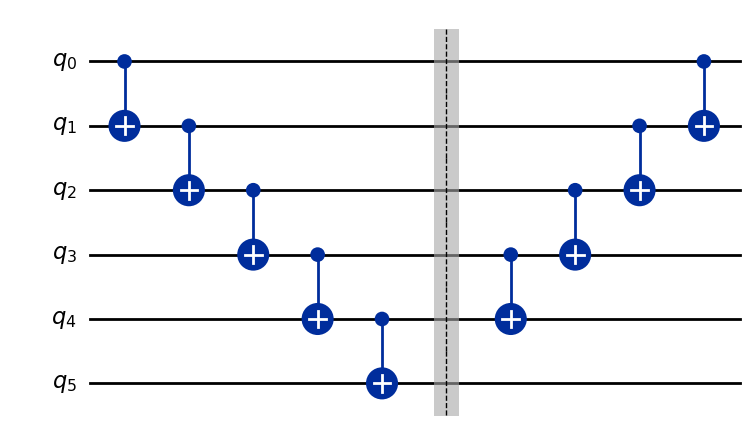

### Strategy Ib

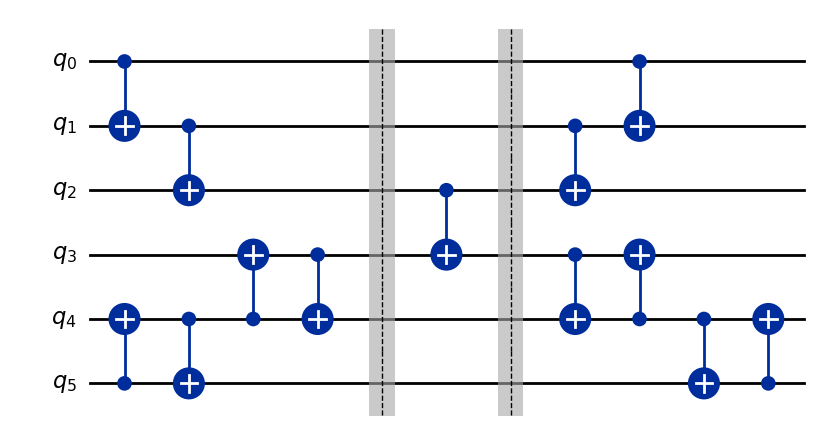

### Strategy Ic

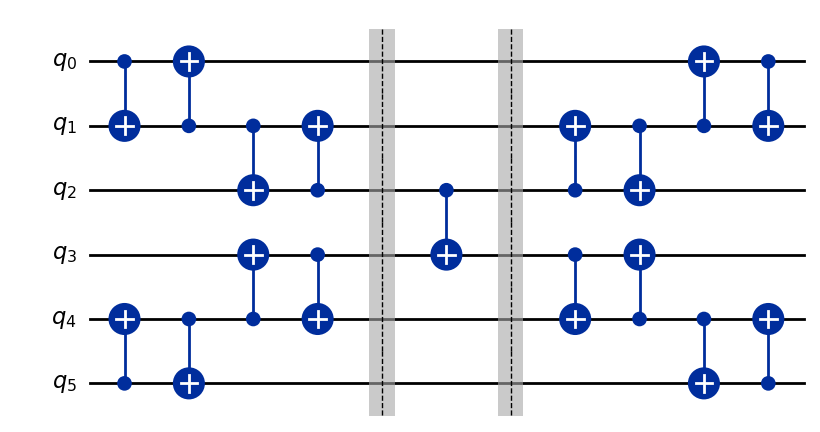

### Strategy II

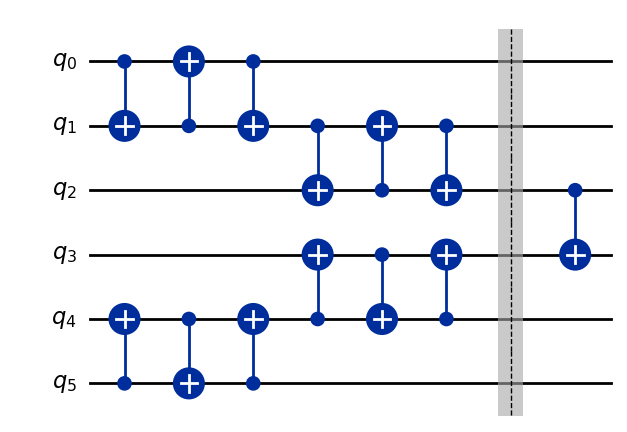

In [11]:
from IPython.display import Markdown, display

# Build all four unitary baselines using the distance from the route found above.
unitary_distance = route_example["num_intermediate_qubits"]
unitary_cnot_circuits = {
    strategy: build_unitary_cnot(strategy, distance=unitary_distance, add_barriers=False)
    for strategy in ["Ia", "Ib", "Ic", "II"]
}

unitary_summary = unitary_resource_table(distance=unitary_distance)
display(unitary_summary)

# Preview small instances to keep the notebook readable.
for strategy in ["Ia", "Ib", "Ic", "II"]:
    display(Markdown(f"### Strategy {strategy}"))
    display(build_unitary_cnot(strategy, distance=4).draw("mpl", fold=-1))

## Dynamic Long-Range CNOT Protocol

This implements the measurement-and-feed-forward long-range CNOT from the paper as a reusable gate block. The circuit acts on a local chain with the control at local qubit `0`, the target at local qubit `distance + 1`, and the intermediate route qubits used as measured bus qubits.

In [6]:
def _new_dynamic_cnot_circuit(distance):
    distance = _validate_distance(distance)
    qr = QuantumRegister(distance + 2, "q")
    classical_registers = []
    zz_count = distance // 2
    xx_count = distance - zz_count

    if zz_count:
        classical_registers.append(ClassicalRegister(zz_count, "c_zz"))
    if xx_count:
        classical_registers.append(ClassicalRegister(xx_count, "c_xx"))

    qc = QuantumCircuit(qr, *classical_registers, name="CNOT_dynamic")
    qc.metadata = {
        "cnot_family": "dynamic",
        "dynamic_strategy": "measurement_feedforward",
        "distance": distance,
        "control_index": 0,
        "target_index": distance + 1,
        "mid_circuit_measure_count": distance,
    }
    return qc, distance


def _dynamic_x0(distance):
    return 1 if distance % 2 == 0 else 2


def _dynamic_registers(qc):
    registers = {register.name: register for register in qc.cregs}
    return registers.get("c_zz"), registers.get("c_xx")


def _dynamic_parity(classical_register):
    parity = None
    for bit in classical_register:
        parity = expr.lift(bit) if parity is None else expr.bit_xor(expr.lift(bit), parity)
    return parity


def prepare_dynamic_bell_pairs(qc, add_barriers=True):
    """Prepare the entangled bus resources used by the dynamic CNOT protocol."""
    distance = qc.num_qubits - 2
    pair_count = distance // 2
    x0 = _dynamic_x0(distance)

    if add_barriers:
        qc.barrier()

    if distance % 2:
        qc.cx(0, 1)

    for pair_index in range(pair_count):
        left = x0 + 2 * pair_index
        qc.h(left)
        qc.cx(left, left + 1)
    return qc


def measure_dynamic_bus(qc, add_barriers=True):
    """Measure the alternating ZZ/XX bus checks needed for feed-forward."""
    distance = qc.num_qubits - 2
    pair_count = distance // 2
    x0 = 1 if distance % 2 == 0 else 2
    c_zz, c_xx = _dynamic_registers(qc)

    if distance > 1 and c_zz is None:
        raise ValueError("Dynamic CNOT circuit is missing the c_zz classical register.")
    if distance > 0 and c_xx is None:
        raise ValueError("Dynamic CNOT circuit is missing the c_xx classical register.")

    for pair_index in range(pair_count + 1):
        qc.cx(x0 - 1 + 2 * pair_index, x0 + 2 * pair_index)

    for meas_index in range(1, pair_count + x0):
        qc.h(2 * meas_index + 1 - x0)

    if add_barriers:
        qc.barrier()

    if distance > 1:
        for meas_index in range(pair_count):
            qc.measure(2 * meas_index + x0, c_zz[meas_index])

    if distance > 0:
        for meas_index in range(1, pair_count + x0):
            qc.measure(2 * meas_index + 1 - x0, c_xx[meas_index - 1])
    return qc


def apply_dynamic_corrections(qc):
    """Apply endpoint corrections conditioned on the measured bus parities."""
    control = 0
    target = qc.num_qubits - 1
    distance = qc.num_qubits - 2
    c_zz, c_xx = _dynamic_registers(qc)

    if distance > 0:
        parity_xx = _dynamic_parity(c_xx)
        with qc.if_test(parity_xx):
            qc.z(control)

    if distance > 1:
        parity_zz = _dynamic_parity(c_zz)
        with qc.if_test(parity_zz):
            qc.x(target)
    return qc


def dynamic_cnot(distance, prep_barrier=True, pre_measure_barrier=True):
    """Build the dynamic long-range CNOT on a route-local 1D chain."""
    qc, _ = _new_dynamic_cnot_circuit(distance)
    prepare_dynamic_bell_pairs(qc, add_barriers=prep_barrier)
    measure_dynamic_bus(qc, add_barriers=pre_measure_barrier)
    apply_dynamic_corrections(qc)
    return qc


def build_dynamic_cnot(distance, add_barriers=True):
    return dynamic_cnot(
        distance=distance,
        prep_barrier=add_barriers,
        pre_measure_barrier=add_barriers,
    )


def dynamic_idle_time_cnot_units(feedback_latency_cnot_units=None):
    """Paper dynamic-circuit idle time: t_idle = 2*mu + 2 CNOT durations."""
    if feedback_latency_cnot_units is None:
        return None
    return 2.0 * float(feedback_latency_cnot_units) + 2.0


def dynamic_error_budget(distance, feedback_latency_cnot_units=None):
    """Return the paper-style error-budget terms for the dynamic protocol."""
    distance = _validate_distance(distance)
    qc = build_dynamic_cnot(distance, add_barriers=False)
    counts = qc.count_ops()
    return {
        "t_idle_formula": "2*mu + 2",
        "t_idle_cnot_units": dynamic_idle_time_cnot_units(feedback_latency_cnot_units),
        "feedback_latency_cnot_units": feedback_latency_cnot_units,
        "N_CNOT": int(counts.get("cx", 0)),
        "N_meas": int(counts.get("measure", 0)),
    }


def dynamic_resource_table(distances, feedback_latency_cnot_units=None):
    if isinstance(distances, int):
        distances = [distances]
    rows = []
    for distance in distances:
        qc = build_dynamic_cnot(distance, add_barriers=False)
        rows.append(
            {
                "strategy": "dynamic",
                **circuit_resource_summary(qc),
                **dynamic_error_budget(distance, feedback_latency_cnot_units=feedback_latency_cnot_units),
            }
        )
    return pd.DataFrame(rows) if pd is not None else rows


,strategy,name,distance,num_qubits,depth,two_qubit_depth,cx_count,swap_count,measure_count,mid_circuit_measure_count,if_else_count,t_idle_formula,t_idle_cnot_units,feedback_latency_cnot_units,N_CNOT,N_meas
0,dynamic,CNOT_dynamic,4,6,6,2,5,0,4,4,2,2*mu + 2,None,None,5,4


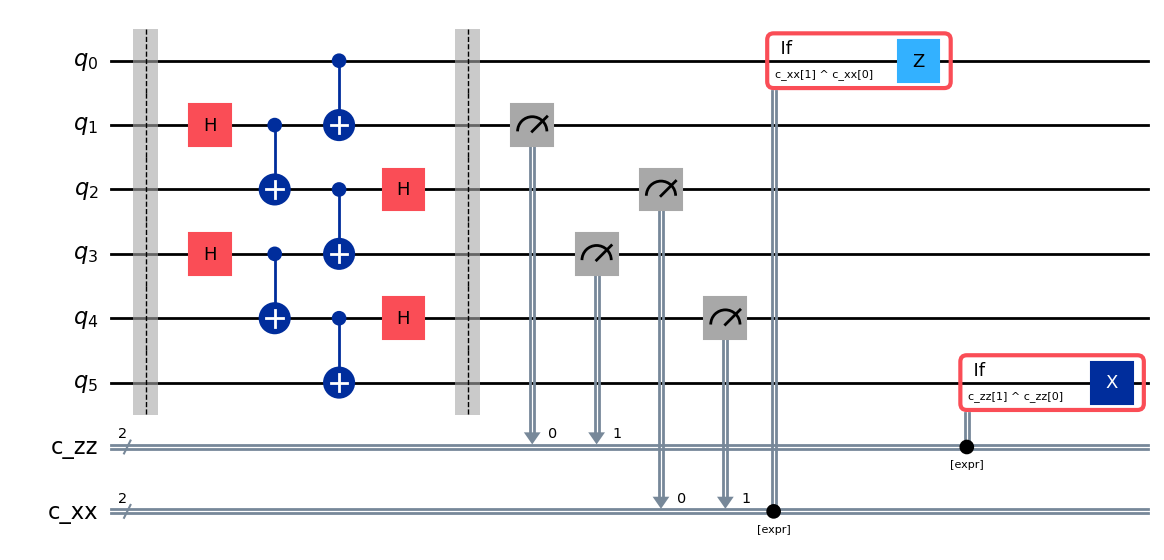

In [6]:
# Preview the dynamic long-range CNOT protocol on a small route-local chain.
dynamic_preview_distance = 4
dynamic_preview = build_dynamic_cnot(dynamic_preview_distance, add_barriers=True)
display(dynamic_resource_table(dynamic_preview_distance))
display(dynamic_preview.draw("mpl", fold=-1))


In [6]:
from qiskit.transpiler import Layout
import json
import re
from datetime import datetime, timezone
from pathlib import Path


def _normalize_runner_backend(runner_backend=None):
    """Accept a backend object, backend-name string, hardware_info dict, or global default."""
    if runner_backend is None:
        runner_backend = globals().get("execution_backend") or globals().get("backend_sim") or globals().get("backend")
    if runner_backend is None:
        raise ValueError("Provide `runner_backend`, or define global `execution_backend`, `backend_sim`, or `backend`.")

    if isinstance(runner_backend, dict):
        if "backend" not in runner_backend:
            raise ValueError("Backend dictionaries must be hardware_info-like and contain a `backend` key.")
        return runner_backend["backend"]

    if isinstance(runner_backend, str):
        runtime_service = globals().get("service")
        if runtime_service is None:
            raise ValueError("Backend-name strings require the global IBM Runtime `service` object.")
        return runtime_service.backend(runner_backend)

    return runner_backend


def _normalize_route_input(route):
    """Accept either a route dictionary from find_cnot_route() or a raw path list."""
    if isinstance(route, dict):
        if "path" not in route:
            raise ValueError("Route dictionaries must contain a `path` key.")
        path = [int(q) for q in route["path"]]
        route_info = dict(route)
    else:
        path = [int(q) for q in route]
        route_info = {}

    if len(path) < 2:
        raise ValueError("A route must contain at least a control and target qubit.")
    if len(set(path)) != len(path):
        raise ValueError("Route qubits must be unique.")

    route_info["path"] = path
    route_info.setdefault("control_qubit", path[0])
    route_info.setdefault("target_qubit", path[-1])
    route_info.setdefault("route_string", " -> ".join(map(str, path)))
    route_info.setdefault("num_edges", len(path) - 1)
    route_info.setdefault("num_intermediate_qubits", max(0, len(path) - 2))
    route_info.setdefault("system_qubits", (path[0], path[-1]))
    route_info.setdefault("ancilla_bus_qubits", path[1:-1])
    return route_info


def _runner_backend_name(backend_obj):
    helper = globals().get("_backend_name")
    if helper is not None:
        try:
            return helper(backend_obj)
        except Exception:
            pass
    name = getattr(backend_obj, "name", None)
    if callable(name):
        return name()
    if name is not None:
        return name
    return type(backend_obj).__name__


def _runner_backend_num_qubits(backend_obj):
    helper = globals().get("_backend_num_qubits")
    if helper is not None:
        try:
            return helper(backend_obj)
        except Exception:
            pass
    num_qubits = getattr(backend_obj, "num_qubits", None)
    if num_qubits is not None:
        return int(num_qubits)
    configuration = getattr(backend_obj, "configuration", None)
    if callable(configuration):
        try:
            return int(configuration().n_qubits)
        except Exception:
            pass
    return None


def _runner_backend_is_simulator(backend_obj):
    configuration = getattr(backend_obj, "configuration", None)
    if callable(configuration):
        try:
            simulator = getattr(configuration(), "simulator", None)
            if simulator is not None:
                return bool(simulator)
        except Exception:
            pass
    module = type(backend_obj).__module__.lower()
    name = str(_runner_backend_name(backend_obj)).lower()
    return "aer" in module or "simulator" in module or "simulator" in name


def _copy_circuit_for_runner(circuit, add_measurements=True):
    qc = circuit.copy(name=f"{circuit.name}_runner")
    if circuit.metadata:
        qc.metadata = dict(circuit.metadata)
    if add_measurements:
        # Dynamic CNOT circuits already contain mid-circuit measurements, so
        # add final readout unless the circuit already has at least one
        # measurement per qubit.
        measure_count = int(qc.count_ops().get("measure", 0))
        if measure_count < qc.num_qubits:
            qc.measure_all(inplace=True)
    return qc


def _route_initial_layout(circuit, route_info):
    path = route_info["path"]
    if circuit.num_qubits != len(path):
        expected_distance = max(0, len(path) - 2)
        circuit_distance = circuit.metadata.get("distance") if circuit.metadata else None
        raise ValueError(
            f"Route length ({len(path)}) must match circuit.num_qubits ({circuit.num_qubits}). "
            f"For this route, build the circuit with distance={expected_distance}. "
            f"Circuit metadata distance={circuit_distance}."
        )
    return Layout.from_intlist(path, *circuit.qregs)


def _runner_two_qubit_depth(circuit):
    return circuit.depth(lambda instr: instr.operation.num_qubits == 2)


def _runner_circuit_summary(prefix, circuit):
    counts = dict(circuit.count_ops())
    return {
        f"{prefix}_num_qubits": circuit.num_qubits,
        f"{prefix}_depth": circuit.depth(),
        f"{prefix}_two_qubit_depth": _runner_two_qubit_depth(circuit),
        f"{prefix}_cx": int(counts.get("cx", 0)),
        f"{prefix}_ecr": int(counts.get("ecr", 0)),
        f"{prefix}_measure": int(counts.get("measure", 0)),
        f"{prefix}_ops": counts,
    }


def _ensure_if_else_target_support(circuits, runner_backend):
    if isinstance(circuits, QuantumCircuit):
        circuits = [circuits]
    if not any("if_else" in circuit.count_ops() for circuit in circuits):
        return

    target = getattr(runner_backend, "target", None)
    if target is None:
        return
    if "if_else" in target.operation_names:
        return
    try:
        target.add_instruction(IfElseOp, name="if_else")
    except Exception as exc:
        raise ValueError(
            f"Backend {_runner_backend_name(runner_backend)} does not advertise if_else support, "
            "and the runner could not add it to the transpiler target."
        ) from exc


def prepare_cnot_route_run(
    circuit,
    route,
    runner_backend=None,
    optimization_level=1,
    seed_transpiler=1234,
    add_measurements=True,
    draw=False,
):
    """Map a route-local CNOT circuit onto the supplied backend without submitting a job."""
    runner_backend = _normalize_runner_backend(runner_backend)
    route_info = _normalize_route_input(route)
    prepared_circuit = _copy_circuit_for_runner(circuit, add_measurements=add_measurements)
    initial_layout = _route_initial_layout(prepared_circuit, route_info)

    backend_num_qubits = _runner_backend_num_qubits(runner_backend)
    if backend_num_qubits is not None and max(route_info["path"]) >= backend_num_qubits:
        raise ValueError(
            f"Route uses physical qubit {max(route_info['path'])}, but backend "
            f"{_runner_backend_name(runner_backend)} has {backend_num_qubits} qubits."
        )

    _ensure_if_else_target_support(prepared_circuit, runner_backend)

    pm = generate_preset_pass_manager(
        optimization_level=optimization_level,
        backend=runner_backend,
        initial_layout=initial_layout,
        seed_transpiler=seed_transpiler,
    )
    transpiled_circuit = pm.run(prepared_circuit)

    summary = {
        "backend_name": _runner_backend_name(runner_backend),
        "backend_is_simulator": _runner_backend_is_simulator(runner_backend),
        "backend_num_qubits": backend_num_qubits,
        "route_string": route_info["route_string"],
        "route_num_edges": route_info["num_edges"],
        "route_distance": route_info["num_intermediate_qubits"],
        "physical_qubits": route_info["path"],
        "optimization_level": optimization_level,
        "seed_transpiler": seed_transpiler,
        "execute": False,
        "execution_mode": "prepared_only",
        "shots": None,
    }
    summary.update(_runner_circuit_summary("input", circuit))
    summary.update(_runner_circuit_summary("prepared", prepared_circuit))
    summary.update(_runner_circuit_summary("transpiled", transpiled_circuit))

    if draw:
        display(transpiled_circuit.draw("mpl", fold=-1, idle_wires=False))

    return {
        "backend": runner_backend,
        "route": route_info,
        "input_circuit": circuit,
        "prepared_circuit": prepared_circuit,
        "transpiled_circuit": transpiled_circuit,
        "initial_layout": initial_layout,
        "pass_manager": pm,
        "job": None,
        "result": None,
        "counts": None,
        "summary": summary,
    }


def _extract_backend_counts(result, circuit=None):
    if result is None or not hasattr(result, "get_counts"):
        return None
    if circuit is not None:
        try:
            return dict(result.get_counts(circuit))
        except Exception:
            pass
    try:
        return dict(result.get_counts(0))
    except Exception:
        pass
    try:
        return dict(result.get_counts())
    except Exception:
        return None


def _sampler_data_register(data, register_name):
    if data is None or register_name is None:
        return None
    try:
        candidate = getattr(data, register_name)
        if hasattr(candidate, "get_counts"):
            return candidate
    except Exception:
        pass
    try:
        candidate = data[register_name]
        if hasattr(candidate, "get_counts"):
            return candidate
    except Exception:
        pass
    return None


def _extract_sampler_pub_counts(pub_result, preferred_register=None):
    data = getattr(pub_result, "data", None)
    if data is None:
        return None

    # SamplerV2 returns separate count containers per classical register. For
    # dynamic process circuits, the syndrome register is often named "c" and
    # appears before the final process-measurement register "proc". Reading the
    # first register therefore makes every Pauli estimate look random.
    register_order = []
    if preferred_register is not None:
        register_order.append(preferred_register)
    register_order.extend(["proc", "meas", "c"])
    for register_name in register_order:
        candidate = _sampler_data_register(data, register_name)
        if candidate is None:
            continue
        try:
            return dict(candidate.get_counts())
        except Exception:
            pass

    candidates = []
    if hasattr(data, "items"):
        try:
            candidates.extend(value for _, value in data.items())
        except Exception:
            pass
    if hasattr(data, "keys"):
        try:
            candidates.extend(getattr(data, key) for key in data.keys())
        except Exception:
            pass
    for name in dir(data):
        if not name.startswith("_"):
            try:
                candidates.append(getattr(data, name))
            except Exception:
                pass

    for candidate in candidates:
        if hasattr(candidate, "get_counts"):
            try:
                return dict(candidate.get_counts())
            except Exception:
                pass
    return None


def _extract_sampler_counts(result, preferred_register=None):
    if result is None:
        return None
    try:
        return _extract_sampler_pub_counts(result[0], preferred_register=preferred_register)
    except Exception:
        return None


def _extract_sampler_counts_list(result, preferred_register=None):
    if result is None:
        return None
    counts_list = []
    try:
        num_results = len(result)
    except Exception:
        num_results = 0
    for index in range(num_results):
        try:
            counts_list.append(_extract_sampler_pub_counts(result[index], preferred_register=preferred_register))
        except Exception:
            counts_list.append(None)
    return counts_list


def _extract_backend_counts_list(result, circuits):
    if result is None or not hasattr(result, "get_counts"):
        return None
    counts_list = []
    for index, circuit in enumerate(circuits):
        counts = None
        try:
            counts = dict(result.get_counts(index))
        except Exception:
            try:
                counts = dict(result.get_counts(circuit))
            except Exception:
                counts = None
        counts_list.append(counts)
    return counts_list


def _runner_job_id(job):
    if job is None:
        return None
    job_id = getattr(job, "job_id", None)
    if callable(job_id):
        try:
            return job_id()
        except Exception:
            return None
    return job_id


def _runner_repo_root():
    cwd = Path.cwd().resolve()
    for path in (cwd, *cwd.parents):
        if (path / ".git").exists():
            return path
    return cwd


def _hardware_run_log_dir(log_dir=None):
    path = Path("log") if log_dir is None else Path(log_dir)
    if not path.is_absolute():
        path = _runner_repo_root() / path
    path.mkdir(parents=True, exist_ok=True)
    return path


def _json_safe(value):
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): _json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [_json_safe(item) for item in value]
    if hasattr(value, "item"):
        try:
            return _json_safe(value.item())
        except Exception:
            pass
    if hasattr(value, "tolist"):
        try:
            return _json_safe(value.tolist())
        except Exception:
            pass
    return repr(value)


def _sanitize_log_token(value):
    token = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value or "unknown")).strip("_")
    return token[:80] or "unknown"


def record_hardware_run(run_data, log_dir=None, event="submitted"):
    """Persist a real-hardware run record as JSON and append it to JSONL."""
    summary = dict(run_data.get("summary", {}))
    if summary.get("backend_is_simulator"):
        return None

    log_dir = _hardware_run_log_dir(log_dir)
    logged_at_utc = datetime.now(timezone.utc).isoformat()
    backend_name = summary.get("backend_name", "unknown_backend")
    job_id = summary.get("job_id") or "no_job_id"
    stem = (
        f"hardware_run_{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}_"
        f"{_sanitize_log_token(backend_name)}_{_sanitize_log_token(job_id)}"
    )
    json_path = log_dir / f"{stem}.json"
    suffix = 1
    while json_path.exists():
        json_path = log_dir / f"{stem}_{suffix}.json"
        suffix += 1
    jsonl_path = log_dir / "hardware_runs.jsonl"

    summary["hardware_log_path"] = str(json_path)
    summary["hardware_log_index"] = str(jsonl_path)
    run_data["summary"].update(
        {
            "hardware_log_path": str(json_path),
            "hardware_log_index": str(jsonl_path),
        }
    )

    input_circuit = run_data.get("input_circuit")
    transpiled_circuit = run_data.get("transpiled_circuit")
    record = {
        "schema_version": 1,
        "event": event,
        "logged_at_utc": logged_at_utc,
        "backend_name": backend_name,
        "job_id": job_id,
        "execution_mode": summary.get("execution_mode"),
        "shots": summary.get("shots"),
        "route": _json_safe(run_data.get("route")),
        "circuit": {
            "input_name": getattr(input_circuit, "name", None),
            "input_metadata": _json_safe(getattr(input_circuit, "metadata", None)),
            "transpiled_name": getattr(transpiled_circuit, "name", None),
            "transpiled_metadata": _json_safe(getattr(transpiled_circuit, "metadata", None)),
        },
        "process_terms": _json_safe(run_data.get("process_terms")),
        "process_specs": _json_safe(run_data.get("process_specs")),
        "fidelity": _json_safe(run_data.get("fidelity")),
        "summary": _json_safe(summary),
        "counts": _json_safe(run_data.get("counts")),
        "log_file": str(json_path),
        "log_index": str(jsonl_path),
    }

    json_text = json.dumps(record, indent=2, sort_keys=True)
    json_path.write_text(json_text + "\n", encoding="utf-8")
    with jsonl_path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record, sort_keys=True) + "\n")
    return {"json": str(json_path), "jsonl": str(jsonl_path)}


def run_cnot_route(
    circuit,
    route,
    runner_backend=None,
    shots=1024,
    execute=False,
    wait_for_result=True,
    primitive="auto",
    configure_qem=False,
    optimization_level=1,
    seed_transpiler=1234,
    add_measurements=True,
    draw=False,
    log_hardware_runs=True,
    hardware_log_dir=None,
):
    """Prepare and optionally execute a route-mapped CNOT circuit.

    execute=False only transpiles and returns a runnable payload. Set execute=True
    explicitly when you want to submit to a simulator or IBM hardware backend.
    Real hardware submissions are logged under repo-root log/ by default.
    """
    run_data = prepare_cnot_route_run(
        circuit=circuit,
        route=route,
        runner_backend=runner_backend,
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler,
        add_measurements=add_measurements,
        draw=draw,
    )

    if primitive not in {"auto", "backend", "sampler"}:
        raise ValueError("primitive must be one of 'auto', 'backend', or 'sampler'.")

    if not execute:
        return run_data

    runner_backend = run_data["backend"]
    selected_primitive = primitive
    if selected_primitive == "auto":
        selected_primitive = "backend" if _runner_backend_is_simulator(runner_backend) and callable(getattr(runner_backend, "run", None)) else "sampler"

    job = None
    result = None
    counts = None
    submitted_at = datetime.now(timezone.utc).isoformat()

    if selected_primitive == "backend":
        run_method = getattr(runner_backend, "run", None)
        if not callable(run_method):
            raise ValueError(f"Backend {_runner_backend_name(runner_backend)} does not expose a callable run() method.")
        job = run_method(run_data["transpiled_circuit"], shots=shots)
        if wait_for_result:
            result = job.result()
            counts = _extract_backend_counts(result, run_data["transpiled_circuit"])
    else:
        sampler = Sampler(mode=runner_backend)
        if configure_qem:
            qem_configurator = globals().get("configure_sampler_qem")
            if qem_configurator is not None:
                sampler = qem_configurator(sampler)
        job = sampler.run([run_data["transpiled_circuit"]], shots=shots)
        if wait_for_result:
            result = job.result()
            counts = _extract_sampler_counts(result)

    run_data.update({"job": job, "result": result, "counts": counts})
    run_data["summary"].update(
        {
            "execute": True,
            "execution_mode": selected_primitive,
            "shots": shots,
            "wait_for_result": wait_for_result,
            "job_id": _runner_job_id(job),
            "submitted_at": submitted_at,
            "counts_extracted": counts is not None,
        }
    )
    if log_hardware_runs and not run_data["summary"].get("backend_is_simulator"):
        record_hardware_run(run_data, log_dir=hardware_log_dir)
    return run_data


CNOT_PROCESS_PAULI_TERMS = [
    {"term": "IIII", "ideal": 1},
    {"term": "IXIX", "ideal": 1},
    {"term": "IYZY", "ideal": 1},
    {"term": "IZZZ", "ideal": 1},
    {"term": "XIXX", "ideal": 1},
    {"term": "XXXI", "ideal": 1},
    {"term": "XYYZ", "ideal": 1},
    {"term": "XZYY", "ideal": -1},
    {"term": "YIYX", "ideal": 1},
    {"term": "YXYI", "ideal": 1},
    {"term": "YYXZ", "ideal": -1},
    {"term": "YZXY", "ideal": 1},
    {"term": "ZIZI", "ideal": 1},
    {"term": "ZXZX", "ideal": 1},
    {"term": "ZYIY", "ideal": 1},
    {"term": "ZZIZ", "ideal": 1},
]


def _local_pauli_prep_options(pauli):
    if pauli == "I":
        return [{"label": "0", "eigenvalue": 1}, {"label": "1", "eigenvalue": 1}]
    if pauli in {"X", "Y", "Z"}:
        return [{"label": "+", "eigenvalue": 1}, {"label": "-", "eigenvalue": -1}]
    raise ValueError(f"Unsupported Pauli {pauli!r}.")


def _prepare_local_pauli_eigenstate(qc, qubit, pauli, option):
    label = option["label"]
    eigenvalue = int(option["eigenvalue"])
    if pauli == "I":
        if label == "1":
            qc.x(qubit)
        return
    if pauli == "Z":
        if eigenvalue == -1:
            qc.x(qubit)
        return
    if eigenvalue == -1:
        qc.x(qubit)
    qc.h(qubit)
    if pauli == "Y":
        qc.s(qubit)


def _measure_local_pauli(qc, qubit, pauli, clbit):
    if pauli == "I":
        return
    if pauli == "X":
        qc.h(qubit)
    elif pauli == "Y":
        qc.sdg(qubit)
        qc.h(qubit)
    elif pauli != "Z":
        raise ValueError(f"Unsupported Pauli {pauli!r}.")
    qc.measure(qubit, clbit)


def _compose_base_cnot_circuit(process_circuit, base_circuit):
    qubits = list(range(base_circuit.num_qubits))
    if base_circuit.num_clbits:
        process_circuit.compose(
            base_circuit,
            qubits=qubits,
            clbits=list(range(base_circuit.num_clbits)),
            inplace=True,
        )
    else:
        process_circuit.compose(base_circuit, qubits=qubits, inplace=True)


def build_cnot_process_circuits(circuit):
    """Build preparation/measurement circuits for the 16 CNOT process terms.

    The identity output term is known exactly, so only 15 terms x 4 input
    eigenstate preparations are executed.
    """
    if circuit.num_qubits < 2:
        raise ValueError("CNOT process certification requires at least two circuit qubits.")
    control = int((circuit.metadata or {}).get("control_index", 0))
    target = int((circuit.metadata or {}).get("target_index", circuit.num_qubits - 1))

    process_terms = []
    process_specs = []
    process_circuits = []

    for term_info in CNOT_PROCESS_PAULI_TERMS:
        term = term_info["term"]
        ideal = int(term_info["ideal"])
        input_pauli = term[:2]
        output_pauli = term[2:]
        process_terms.append(
            {
                "term": term,
                "ideal": ideal,
                "input_pauli": input_pauli,
                "output_pauli": output_pauli,
                "executed": output_pauli != "II",
            }
        )
        if output_pauli == "II":
            continue

        control_options = _local_pauli_prep_options(input_pauli[0])
        target_options = _local_pauli_prep_options(input_pauli[1])
        for control_option in control_options:
            for target_option in target_options:
                qc = QuantumCircuit(circuit.num_qubits, circuit.num_clbits, name=f"proc_{term}")
                _prepare_local_pauli_eigenstate(qc, control, input_pauli[0], control_option)
                _prepare_local_pauli_eigenstate(qc, target, input_pauli[1], target_option)
                _compose_base_cnot_circuit(qc, circuit)

                measured_qubits = [
                    qubit for qubit, pauli in [(control, output_pauli[0]), (target, output_pauli[1])] if pauli != "I"
                ]
                process_register = ClassicalRegister(len(measured_qubits), "proc")
                qc.add_register(process_register)

                measured_clbits = []
                measured_register_bits = []
                next_clbit = 0
                for qubit, pauli in [(control, output_pauli[0]), (target, output_pauli[1])]:
                    if pauli == "I":
                        continue
                    _measure_local_pauli(qc, qubit, pauli, process_register[next_clbit])
                    measured_clbits.append(qc.find_bit(process_register[next_clbit]).index)
                    measured_register_bits.append(next_clbit)
                    next_clbit += 1

                prep_weight = int(control_option["eigenvalue"] * target_option["eigenvalue"])
                spec = {
                    "term": term,
                    "ideal": ideal,
                    "input_pauli": input_pauli,
                    "output_pauli": output_pauli,
                    "control_prep": dict(control_option),
                    "target_prep": dict(target_option),
                    "prep_weight": prep_weight,
                    "prep_average_weight": 0.25,
                    "measured_clbits": measured_clbits,
                    "num_clbits": qc.num_clbits,
                    "measurement_register": "proc",
                    "measured_register_bits": measured_register_bits,
                    "measurement_register_size": len(process_register),
                    "circuit_index": len(process_circuits),
                }
                qc.metadata = dict(circuit.metadata or {})
                qc.metadata.update({"process_certification": spec})
                process_specs.append(spec)
                process_circuits.append(qc)

    return {
        "terms": process_terms,
        "specs": process_specs,
        "circuits": process_circuits,
    }


def _counts_total_shots(counts):
    return int(sum(int(value) for value in counts.values())) if counts else 0


def _count_key_to_bits(count_key, total_clbits):
    clean = str(count_key).replace(" ", "")
    if clean.startswith("0x"):
        bits = bin(int(clean, 16))[2:]
    else:
        bits = "".join(char for char in clean if char in "01")
    if total_clbits:
        bits = bits.zfill(total_clbits)
    return bits


def _counts_pauli_expectation(counts, measured_clbits, total_clbits):
    if not measured_clbits:
        return 1.0
    shots = _counts_total_shots(counts)
    if shots == 0:
        return None
    total = 0.0
    for count_key, count in counts.items():
        bits = _count_key_to_bits(count_key, total_clbits)
        eigenvalue = 1
        for clbit in measured_clbits:
            bit = bits[-1 - clbit] if clbit < len(bits) else "0"
            eigenvalue *= -1 if bit == "1" else 1
        total += eigenvalue * int(count)
    return total / shots


def calculate_cnot_process_fidelity(process_specs, counts_list, process_terms=None, counts_register=None):
    if counts_list is None:
        return None
    process_terms = process_terms or CNOT_PROCESS_PAULI_TERMS
    term_estimates = {"IIII": 1.0}
    term_shots = {"IIII": None}
    partial_sums = {}
    partial_shots = {}

    for spec, counts in zip(process_specs, counts_list):
        if counts is None:
            return None
        if counts_register is not None and counts_register == spec.get("measurement_register"):
            measured_bits = spec.get("measured_register_bits", spec["measured_clbits"])
            num_bits = spec.get("measurement_register_size", spec["num_clbits"])
        else:
            measured_bits = spec["measured_clbits"]
            num_bits = spec["num_clbits"]
        expectation = _counts_pauli_expectation(counts, measured_bits, num_bits)
        if expectation is None:
            return None
        term = spec["term"]
        partial_sums[term] = partial_sums.get(term, 0.0) + spec["prep_average_weight"] * spec["prep_weight"] * expectation
        partial_shots[term] = partial_shots.get(term, 0) + _counts_total_shots(counts)

    for term, estimate in partial_sums.items():
        term_estimates[term] = estimate
        term_shots[term] = partial_shots.get(term)

    rows = []
    process_sum = 0.0
    for term_info in process_terms:
        term = term_info["term"]
        ideal = int(term_info["ideal"])
        estimate = term_estimates.get(term)
        if estimate is None:
            return None
        contribution = ideal * estimate / 16.0
        process_sum += contribution
        rows.append(
            {
                "term": term,
                "ideal": ideal,
                "estimate": estimate,
                "ideal_times_estimate": ideal * estimate,
                "process_contribution": contribution,
                "shots": term_shots.get(term),
            }
        )

    return {
        "process_fidelity": process_sum,
        "gate_fidelity": (4.0 * process_sum + 1.0) / 5.0,
        "term_rows": rows,
    }


def prepare_cnot_process_run(
    circuit,
    route,
    runner_backend=None,
    optimization_level=1,
    seed_transpiler=1234,
):
    runner_backend = _normalize_runner_backend(runner_backend)
    route_info = _normalize_route_input(route)
    process_payload = build_cnot_process_circuits(circuit)
    process_circuits = process_payload["circuits"]
    if not process_circuits:
        raise ValueError("No executable process-certification circuits were generated.")
    initial_layout = _route_initial_layout(process_circuits[0], route_info)

    backend_num_qubits = _runner_backend_num_qubits(runner_backend)
    if backend_num_qubits is not None and max(route_info["path"]) >= backend_num_qubits:
        raise ValueError(
            f"Route uses physical qubit {max(route_info['path'])}, but backend "
            f"{_runner_backend_name(runner_backend)} has {backend_num_qubits} qubits."
        )

    _ensure_if_else_target_support(process_circuits, runner_backend)

    pm = generate_preset_pass_manager(
        optimization_level=optimization_level,
        backend=runner_backend,
        initial_layout=initial_layout,
        seed_transpiler=seed_transpiler,
    )
    transpiled_circuits = pm.run(process_circuits)

    summary = {
        "backend_name": _runner_backend_name(runner_backend),
        "backend_is_simulator": _runner_backend_is_simulator(runner_backend),
        "backend_num_qubits": backend_num_qubits,
        "route_string": route_info["route_string"],
        "route_num_edges": route_info["num_edges"],
        "route_distance": route_info["num_intermediate_qubits"],
        "physical_qubits": route_info["path"],
        "optimization_level": optimization_level,
        "seed_transpiler": seed_transpiler,
        "execute": False,
        "execution_mode": "prepared_only",
        "shots": None,
        "process_term_count": len(process_payload["terms"]),
        "process_circuit_count": len(process_circuits),
        "process_identity_terms": 1,
        "input_name": circuit.name,
        "input_num_qubits": circuit.num_qubits,
        "input_depth": circuit.depth(),
        "transpiled_circuit_count": len(transpiled_circuits),
        "max_transpiled_depth": max(qc.depth() for qc in transpiled_circuits),
    }

    return {
        "backend": runner_backend,
        "route": route_info,
        "input_circuit": circuit,
        "prepared_circuits": process_circuits,
        "transpiled_circuits": transpiled_circuits,
        "transpiled_circuit": transpiled_circuits[0],
        "initial_layout": initial_layout,
        "pass_manager": pm,
        "process_terms": process_payload["terms"],
        "process_specs": process_payload["specs"],
        "job": None,
        "result": None,
        "counts": None,
        "fidelity": None,
        "summary": summary,
    }


def run_cnot_process_fidelity(
    circuit,
    route,
    runner_backend=None,
    shots=1024,
    execute=False,
    wait_for_result=True,
    primitive="auto",
    configure_qem=False,
    optimization_level=1,
    seed_transpiler=1234,
    log_hardware_runs=True,
    hardware_log_dir=None,
):
    run_data = prepare_cnot_process_run(
        circuit=circuit,
        route=route,
        runner_backend=runner_backend,
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler,
    )

    if primitive not in {"auto", "backend", "sampler"}:
        raise ValueError("primitive must be one of 'auto', 'backend', or 'sampler'.")
    if not execute:
        return run_data

    runner_backend = run_data["backend"]
    selected_primitive = primitive
    if selected_primitive == "auto":
        selected_primitive = "backend" if _runner_backend_is_simulator(runner_backend) and callable(getattr(runner_backend, "run", None)) else "sampler"

    job = None
    result = None
    counts_list = None
    submitted_at = datetime.now(timezone.utc).isoformat()

    if selected_primitive == "backend":
        run_method = getattr(runner_backend, "run", None)
        if not callable(run_method):
            raise ValueError(f"Backend {_runner_backend_name(runner_backend)} does not expose a callable run() method.")
        job = run_method(run_data["transpiled_circuits"], shots=shots)
        if wait_for_result:
            result = job.result()
            counts_list = _extract_backend_counts_list(result, run_data["transpiled_circuits"])
    else:
        sampler = Sampler(mode=runner_backend)
        if configure_qem:
            qem_configurator = globals().get("configure_sampler_qem")
            if qem_configurator is not None:
                sampler = qem_configurator(sampler)
        job = sampler.run(run_data["transpiled_circuits"], shots=shots)
        if wait_for_result:
            result = job.result()
            counts_list = _extract_sampler_counts_list(result, preferred_register="proc")

    fidelity = calculate_cnot_process_fidelity(
        run_data["process_specs"],
        counts_list,
        run_data["process_terms"],
        counts_register="proc" if selected_primitive == "sampler" else None,
    )
    run_data.update({"job": job, "result": result, "counts": counts_list, "fidelity": fidelity})
    run_data["summary"].update(
        {
            "execute": True,
            "execution_mode": selected_primitive,
            "shots": shots,
            "wait_for_result": wait_for_result,
            "job_id": _runner_job_id(job),
            "submitted_at": submitted_at,
            "counts_extracted": counts_list is not None,
            "process_fidelity": None if fidelity is None else fidelity["process_fidelity"],
            "gate_fidelity": None if fidelity is None else fidelity["gate_fidelity"],
        }
    )
    if log_hardware_runs and not run_data["summary"].get("backend_is_simulator"):
        record_hardware_run(run_data, log_dir=hardware_log_dir, event="process_submitted")
    return run_data


def display_cnot_process_run(run_data, max_terms=16):
    summary = run_data["summary"]
    display_keys = [
        "backend_name",
        "backend_is_simulator",
        "execution_mode",
        "execute",
        "shots",
        "route_string",
        "route_distance",
        "process_term_count",
        "process_circuit_count",
        "counts_extracted",
        "process_fidelity",
        "gate_fidelity",
        "job_id",
        "hardware_log_path",
    ]
    row = {key: summary.get(key) for key in display_keys if key in summary}
    if "pd" in globals() and pd is not None:
        display(pd.DataFrame([row]))
    else:
        print(row)

    fidelity = run_data.get("fidelity")
    if fidelity and fidelity.get("term_rows"):
        rows = fidelity["term_rows"][:max_terms]
        if "pd" in globals() and pd is not None:
            display(pd.DataFrame(rows))
        else:
            print(rows)


def display_cnot_run(run_data, max_counts=10):
    summary = run_data["summary"]
    display_keys = [
        "backend_name",
        "backend_is_simulator",
        "execution_mode",
        "execute",
        "shots",
        "route_string",
        "route_num_edges",
        "route_distance",
        "input_num_qubits",
        "input_depth",
        "input_cx",
        "prepared_depth",
        "prepared_measure",
        "transpiled_num_qubits",
        "transpiled_depth",
        "transpiled_two_qubit_depth",
        "transpiled_cx",
        "transpiled_ecr",
        "transpiled_measure",
        "counts_extracted",
        "job_id",
        "hardware_log_path",
    ]
    row = {key: summary.get(key) for key in display_keys if key in summary}
    if "pd" in globals() and pd is not None:
        display(pd.DataFrame([row]))
    else:
        print(row)

    counts = run_data.get("counts")
    if counts:
        top_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:max_counts]
        if "pd" in globals() and pd is not None:
            display(pd.DataFrame(top_counts, columns=["bitstring", "shots"]))
        else:
            print(top_counts)


# Local smoke run: proves the runner path without submitting to IBM hardware.
RUNNER_SMOKE_TEST = True
runner_smoke_backend = AerSimulator()
runner_smoke_route = find_cnot_route(0, 2, edges=[(0, 1), (1, 2)], directed=False)
runner_smoke_unitary = build_unitary_cnot("Ia", distance=runner_smoke_route["num_intermediate_qubits"], add_barriers=False)
runner_smoke_circuit = QuantumCircuit(runner_smoke_unitary.num_qubits, name="runner_smoke_Ia")
runner_smoke_circuit.x(0)
runner_smoke_circuit.compose(runner_smoke_unitary, qubits=list(range(runner_smoke_unitary.num_qubits)), inplace=True)
runner_smoke_circuit.metadata = dict(runner_smoke_unitary.metadata or {})
runner_smoke_circuit.metadata["input_state"] = "control=1,target=0"

if RUNNER_SMOKE_TEST:
    runner_smoke = run_cnot_route(
        runner_smoke_circuit,
        runner_smoke_route,
        runner_backend=runner_smoke_backend,
        shots=128,
        execute=True,
        primitive="backend",
        optimization_level=1,
        seed_transpiler=1234,
    )
    display_cnot_run(runner_smoke)

    runner_process_smoke_route = find_cnot_route(0, 1, edges=[(0, 1)], directed=False)
    runner_process_smoke_circuit = build_unitary_cnot("Ic", distance=0, add_barriers=False)
    runner_process_smoke = run_cnot_process_fidelity(
        runner_process_smoke_circuit,
        runner_process_smoke_route,
        runner_backend=AerSimulator(),
        shots=256,
        execute=True,
        primitive="backend",
        optimization_level=1,
        seed_transpiler=1234,
    )
    display_cnot_process_run(runner_process_smoke)


,backend_name,backend_is_simulator,execution_mode,execute,shots,route_string,route_num_edges,route_distance,input_num_qubits,input_depth,...,prepared_depth,prepared_measure,transpiled_num_qubits,transpiled_depth,transpiled_two_qubit_depth,transpiled_cx,transpiled_ecr,transpiled_measure,counts_extracted,job_id
0,aer_simulator,True,backend,True,128,0 -> 1 -> 2,2,1,3,4,...,5,3,28,5,3,3,0,3,True,e119f445-d314-48db-8f9a-58f6ddb1e12f


,bitstring,shots
0,101,128


,backend_name,backend_is_simulator,execution_mode,execute,shots,route_string,route_distance,process_term_count,process_circuit_count,counts_extracted,process_fidelity,gate_fidelity,job_id
0,aer_simulator,True,backend,True,256,0 -> 1,0,16,60,True,1.0,1.0,f1f0e195-24ca-48e2-b026-9a0ab67407a8


,term,ideal,estimate,ideal_times_estimate,process_contribution,shots
0,IIII,1,1.0,1.0,0.0625,NaN
1,IXIX,1,1.0,1.0,0.0625,1024.0
2,IYZY,1,1.0,1.0,0.0625,1024.0
3,IZZZ,1,1.0,1.0,0.0625,1024.0
4,XIXX,1,1.0,1.0,0.0625,1024.0
5,XXXI,1,1.0,1.0,0.0625,1024.0
6,XYYZ,1,1.0,1.0,0.0625,1024.0
7,XZYY,-1,-1.0,1.0,0.0625,1024.0
8,YIYX,1,1.0,1.0,0.0625,1024.0
9,YXYI,1,1.0,1.0,0.0625,1024.0


In [8]:
# Local dynamic-circuit smoke run: this uses Aer only and does not submit IBM hardware jobs.
DYNAMIC_RUNNER_SMOKE_TEST = True

dynamic_smoke_route = find_cnot_route(0, 3, edges=[(0, 1), (1, 2), (2, 3)], directed=False)
dynamic_smoke_circuit = build_dynamic_cnot(
    distance=dynamic_smoke_route["num_intermediate_qubits"],
    add_barriers=False,
)

if DYNAMIC_RUNNER_SMOKE_TEST:
    dynamic_smoke_run = run_cnot_route(
        dynamic_smoke_circuit,
        dynamic_smoke_route,
        runner_backend=AerSimulator(),
        shots=128,
        execute=True,
        primitive="backend",
        optimization_level=1,
        seed_transpiler=1234,
    )
    display_cnot_run(dynamic_smoke_run)

    dynamic_process_smoke = run_cnot_process_fidelity(
        dynamic_smoke_circuit,
        dynamic_smoke_route,
        runner_backend=AerSimulator(),
        shots=256,
        execute=True,
        primitive="backend",
        optimization_level=1,
        seed_transpiler=1234,
    )
    display_cnot_process_run(dynamic_process_smoke)


,backend_name,backend_is_simulator,execution_mode,execute,shots,route_string,route_num_edges,route_distance,input_num_qubits,input_depth,...,prepared_depth,prepared_measure,transpiled_num_qubits,transpiled_depth,transpiled_two_qubit_depth,transpiled_cx,transpiled_ecr,transpiled_measure,counts_extracted,job_id
0,aer_simulator,True,backend,True,128,0 -> 1 -> 2 -> 3,3,2,4,6,...,7,6,28,7,2,3,0,6,True,fe9017c6-5673-4fd0-832f-51a7b54f0aad


,bitstring,shots
0,0100 1 0,37
1,0010 0 1,37
2,0000 0 0,30
3,0110 1 1,24


,backend_name,backend_is_simulator,execution_mode,execute,shots,route_string,route_distance,process_term_count,process_circuit_count,counts_extracted,process_fidelity,gate_fidelity,job_id
0,aer_simulator,True,backend,True,256,0 -> 1 -> 2 -> 3,2,16,60,True,1.0,1.0,71e11e11-b74a-4ec7-8b5c-92c0102907a4


,term,ideal,estimate,ideal_times_estimate,process_contribution,shots
0,IIII,1,1.0,1.0,0.0625,NaN
1,IXIX,1,1.0,1.0,0.0625,1024.0
2,IYZY,1,1.0,1.0,0.0625,1024.0
3,IZZZ,1,1.0,1.0,0.0625,1024.0
4,XIXX,1,1.0,1.0,0.0625,1024.0
5,XXXI,1,1.0,1.0,0.0625,1024.0
6,XYYZ,1,1.0,1.0,0.0625,1024.0
7,XZYY,-1,-1.0,1.0,0.0625,1024.0
8,YIYX,1,1.0,1.0,0.0625,1024.0
9,YXYI,1,1.0,1.0,0.0625,1024.0


## IBM Fez Real-Hardware Distance Sweep: Unitary Ic vs Dynamic

This section submits the same even-distance sweep to real IBM hardware on `ibm_fez`. Each implementation/distance is one Runtime Sampler process-fidelity job with 60 Pauli-certification circuits. Submission records are written immediately; completed jobs can be fetched later by rerunning the monitor cell.

In [8]:
# Real hardware sweep submission: ibm_fez, unitary Ic vs dynamic.
# This submits one Runtime Sampler job per (distance, circuit) pair and logs job IDs immediately.
import time
from qiskit_ibm_runtime import QiskitRuntimeService

IBM_FEZ_SWEEP_BACKEND_NAME = "ibm_fez"
IBM_FEZ_SWEEP_DISTANCES = list(range(2, 61, 2))
IBM_FEZ_SWEEP_SHOTS = 128
IBM_FEZ_SWEEP_OPTIMIZATION_LEVEL = 1
IBM_FEZ_SWEEP_SEED = 1234
IBM_FEZ_SWEEP_CONFIGURE_QEM = False
IBM_FEZ_SWEEP_LOG_DIR = "log/ibm_fez_distance_sweep"
IBM_FEZ_SWEEP_RESUME = True
IBM_FEZ_SWEEP_SUBMIT_LIMIT = None  # Set to an integer to throttle new submissions.


def ibm_distance_sweep_log_paths(log_dir=None):
    log_path = _hardware_run_log_dir(log_dir or IBM_FEZ_SWEEP_LOG_DIR)
    return log_path, log_path / "ibm_fez_distance_sweep.jsonl"


def load_ibm_fez_sweep_records(log_dir=None):
    _, jsonl_path = ibm_distance_sweep_log_paths(log_dir)
    records = []
    if not jsonl_path.exists():
        return records
    with jsonl_path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return records


def write_ibm_fez_sweep_record(record, log_dir=None):
    log_path, jsonl_path = ibm_distance_sweep_log_paths(log_dir)
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    filename = (
        f"ibm_fez_distance_{int(record['distance']):02d}_"
        f"{_sanitize_log_token(record['circuit'])}_"
        f"{_sanitize_log_token(record['event'])}_"
        f"shots_{record['shots_per_circuit']}_{timestamp}.json"
    )
    record_path = log_path / filename
    safe_record = _json_safe(record)
    with record_path.open("w", encoding="utf-8") as handle:
        json.dump(safe_record, handle, indent=2, sort_keys=True)
    with jsonl_path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(safe_record, sort_keys=True) + "\n")
    return record_path


def ibm_fez_sweep_key(distance, circuit, shots=IBM_FEZ_SWEEP_SHOTS, optimization_level=IBM_FEZ_SWEEP_OPTIMIZATION_LEVEL):
    return (int(distance), str(circuit), int(shots), int(optimization_level))


def completed_or_submitted_ibm_fez_keys(records):
    keys = set()
    for record in records:
        if record.get("backend") != IBM_FEZ_SWEEP_BACKEND_NAME:
            continue
        if record.get("event") not in {"submitted", "completed"}:
            continue
        keys.add(
            ibm_fez_sweep_key(
                record.get("distance"),
                record.get("circuit"),
                record.get("shots_per_circuit"),
                record.get("optimization_level", IBM_FEZ_SWEEP_OPTIMIZATION_LEVEL),
            )
        )
    return keys


def ibm_hardware_neighbors(backend_obj):
    neighbors = {q: set() for q in range(_backend_num_qubits(backend_obj))}
    for u, v in _extract_coupling_edges(hardware=backend_obj):
        neighbors[int(u)].add(int(v))
        neighbors[int(v)].add(int(u))
    return neighbors


def find_connected_hardware_bus_path(backend_obj, distance, start_preference=0):
    distance = _validate_distance(distance)
    target_length = distance + 2
    neighbors = ibm_hardware_neighbors(backend_obj)
    starts = [start_preference] + [q for q in sorted(neighbors) if q != start_preference]
    found = None

    def dfs(path, visited):
        nonlocal found
        if len(path) == target_length:
            found = list(path)
            return True
        for neighbor in sorted(neighbors[path[-1]]):
            if neighbor in visited:
                continue
            visited.add(neighbor)
            path.append(neighbor)
            if dfs(path, visited):
                return True
            path.pop()
            visited.remove(neighbor)
        return False

    for start in starts:
        if dfs([start], {start}):
            return found
    raise ValueError(f"Could not find a connected {IBM_FEZ_SWEEP_BACKEND_NAME} bus path for distance={distance}.")


def route_from_hardware_bus_path(path, directed=False):
    path = [int(q) for q in path]
    return {
        "control_qubit": path[0],
        "target_qubit": path[-1],
        "path": path,
        "route_string": " -> ".join(map(str, path)),
        "num_edges": len(path) - 1,
        "num_intermediate_qubits": len(path) - 2,
        "system_qubits": (path[0], path[-1]),
        "ancilla_bus_qubits": path[1:-1],
        "directed": directed,
        "blocked_qubits": [],
    }


def build_ibm_fez_sweep_circuit(label, distance):
    if label == "unitary Ic":
        return build_unitary_cnot("Ic", distance=distance, add_barriers=False)
    if label == "dynamic":
        return build_dynamic_cnot(distance=distance, add_barriers=False)
    raise ValueError("label must be 'unitary Ic' or 'dynamic'.")


def make_ibm_fez_submission_record(label, distance, route, run_data, elapsed_s):
    summary = dict(run_data["summary"])
    circuit = run_data["input_circuit"]
    counts = circuit.count_ops()
    return {
        "event": "submitted",
        "created_at": datetime.now(timezone.utc).isoformat(),
        "backend": IBM_FEZ_SWEEP_BACKEND_NAME,
        "backend_reported_name": summary.get("backend_name"),
        "backend_is_simulator": summary.get("backend_is_simulator"),
        "circuit": label,
        "input_circuit_name": circuit.name,
        "distance": int(distance),
        "route": route["route_string"],
        "path": route["path"],
        "route_edges": route["num_edges"],
        "job_id": summary.get("job_id"),
        "job_status": "submitted",
        "process_fidelity": None,
        "gate_fidelity": None,
        "process_circuits": summary.get("process_circuit_count"),
        "shots_per_circuit": summary.get("shots"),
        "optimization_level": summary.get("optimization_level"),
        "seed_transpiler": summary.get("seed_transpiler"),
        "configure_qem": IBM_FEZ_SWEEP_CONFIGURE_QEM,
        "elapsed_s": elapsed_s,
        "input_depth": circuit.depth(),
        "input_cx": int(counts.get("cx", 0)),
        "input_measure": int(counts.get("measure", 0)),
        "input_if_else": int(counts.get("if_else", 0)),
        "max_transpiled_depth": summary.get("max_transpiled_depth"),
    }


def ibm_fez_records_dataframe(records):
    rows = []
    for record in records:
        if record.get("backend") != IBM_FEZ_SWEEP_BACKEND_NAME:
            continue
        rows.append(
            {
                "event": record.get("event"),
                "distance": record.get("distance"),
                "circuit": record.get("circuit"),
                "job_id": record.get("job_id"),
                "job_status": record.get("job_status"),
                "process_fidelity": record.get("process_fidelity"),
                "gate_fidelity": record.get("gate_fidelity"),
                "route": record.get("route"),
                "shots_per_circuit": record.get("shots_per_circuit"),
                "process_circuits": record.get("process_circuits"),
                "elapsed_s": record.get("elapsed_s"),
            }
        )
    if pd is None:
        return rows
    return pd.DataFrame(rows).sort_values(["distance", "circuit", "event"]).reset_index(drop=True)


def submit_ibm_fez_distance_sweep(
    distances=IBM_FEZ_SWEEP_DISTANCES,
    shots=IBM_FEZ_SWEEP_SHOTS,
    resume=IBM_FEZ_SWEEP_RESUME,
    submit_limit=IBM_FEZ_SWEEP_SUBMIT_LIMIT,
    log_dir=IBM_FEZ_SWEEP_LOG_DIR,
):
    try:
        runtime_service = QiskitRuntimeService(name=ACCOUNT_NAME)
    except Exception:
        runtime_service = QiskitRuntimeService()
    backend_obj = runtime_service.backend(IBM_FEZ_SWEEP_BACKEND_NAME)
    status = backend_obj.status()
    print(
        f"Backend {IBM_FEZ_SWEEP_BACKEND_NAME}: operational={status.operational}, "
        f"pending_jobs={status.pending_jobs}",
        flush=True,
    )
    if "if_else" not in backend_obj.target.operation_names:
        backend_obj.target.add_instruction(IfElseOp, name="if_else")

    existing_records = load_ibm_fez_sweep_records(log_dir)
    existing_keys = completed_or_submitted_ibm_fez_keys(existing_records) if resume else set()
    new_records = []
    submitted_count = 0

    print(f"Distances: {list(distances)}", flush=True)
    print(f"Shots per process circuit: {shots}", flush=True)
    print(f"Log dir: {ibm_distance_sweep_log_paths(log_dir)[0]}", flush=True)

    for distance in distances:
        path = find_connected_hardware_bus_path(backend_obj, distance)
        route = route_from_hardware_bus_path(path)
        print(f"\nDistance {distance}: {route['route_string']}", flush=True)

        for label in ["unitary Ic", "dynamic"]:
            key = ibm_fez_sweep_key(distance, label, shots, IBM_FEZ_SWEEP_OPTIMIZATION_LEVEL)
            if key in existing_keys:
                print(f"skip existing {label}", flush=True)
                continue
            if submit_limit is not None and submitted_count >= submit_limit:
                print("submit limit reached", flush=True)
                records = load_ibm_fez_sweep_records(log_dir)
                display(ibm_fez_records_dataframe(records))
                return records

            circuit = build_ibm_fez_sweep_circuit(label, distance)
            started = time.perf_counter()
            try:
                run_data = run_cnot_process_fidelity(
                    circuit,
                    route,
                    runner_backend=backend_obj,
                    shots=shots,
                    execute=True,
                    wait_for_result=False,
                    primitive="sampler",
                    configure_qem=IBM_FEZ_SWEEP_CONFIGURE_QEM,
                    optimization_level=IBM_FEZ_SWEEP_OPTIMIZATION_LEVEL,
                    seed_transpiler=IBM_FEZ_SWEEP_SEED,
                    log_hardware_runs=True,
                    hardware_log_dir=log_dir,
                )
                elapsed_s = time.perf_counter() - started
                record = make_ibm_fez_submission_record(label, distance, route, run_data, elapsed_s)
                record_path = write_ibm_fez_sweep_record(record, log_dir=log_dir)
                new_records.append(record)
                existing_keys.add(key)
                submitted_count += 1
                print(
                    f"submitted {label}: job_id={record['job_id']}, "
                    f"elapsed={elapsed_s:.1f}s, log={record_path.name}",
                    flush=True,
                )
            except Exception as exc:
                elapsed_s = time.perf_counter() - started
                error_record = {
                    "event": "submit_error",
                    "created_at": datetime.now(timezone.utc).isoformat(),
                    "backend": IBM_FEZ_SWEEP_BACKEND_NAME,
                    "circuit": label,
                    "distance": int(distance),
                    "route": route["route_string"],
                    "path": route["path"],
                    "shots_per_circuit": int(shots),
                    "optimization_level": int(IBM_FEZ_SWEEP_OPTIMIZATION_LEVEL),
                    "configure_qem": IBM_FEZ_SWEEP_CONFIGURE_QEM,
                    "elapsed_s": elapsed_s,
                    "error_type": type(exc).__name__,
                    "error": str(exc),
                }
                record_path = write_ibm_fez_sweep_record(error_record, log_dir=log_dir)
                new_records.append(error_record)
                print(f"ERROR {label}: {type(exc).__name__}: {exc} (log={record_path.name})", flush=True)

    records = load_ibm_fez_sweep_records(log_dir)
    display(ibm_fez_records_dataframe(records))
    return records


ibm_fez_submission_records = submit_ibm_fez_distance_sweep()


Backend ibm_fez: operational=True, pending_jobs=32


Distances: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]


Shots per process circuit: 128


Log dir: /home/arnold/arnold/github/qhackathon_quantumjoa/log/ibm_fez_distance_sweep



Distance 2: 0 -> 1 -> 2 -> 3


...

skip existing dynamic



Distance 60: 0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9 -> 10 -> 11 -> 12 -> 13 -> 14 -> 15 -> 19 -> 35 -> 34 -> 33 -> 32 -> 31 -> 30 -> 29 -> 28 -> 27 -> 26 -> 25 -> 24 -> 23 -> 22 -> 21 -> 36 -> 41 -> 42 -> 43 -> 44 -> 45 -> 46 -> 47 -> 48 -> 49 -> 50 -> 51 -> 52 -> 53 -> 54 -> 55 -> 59 -> 75 -> 74 -> 73 -> 72 -> 71 -> 70 -> 69 -> 68 -> 67 -> 66 -> 65 -> 64 -> 63


skip existing unitary Ic


skip existing dynamic


,event,distance,circuit,job_id,job_status,process_fidelity,gate_fidelity,route,shots_per_circuit,process_circuits,elapsed_s
0,completed,2,dynamic,d915p4eu9n7c73am1jbg,DONE,0.062500,0.250000,0 -> 1 -> 2 -> 3,64,60,3.466613
1,completed,2,dynamic,d915p4eu9n7c73am1jbg,DONE,0.528320,0.622656,0 -> 1 -> 2 -> 3,64,60,3.741571
2,submitted,2,dynamic,d915p4eu9n7c73am1jbg,submitted,NaN,NaN,0 -> 1 -> 2 -> 3,64,60,7.257872
3,submitted,2,dynamic,d916cq7qq29s738n0vvg,submitted,NaN,NaN,0 -> 1 -> 2 -> 3,128,60,5.530426
4,completed,2,unitary Ic,d915p2fqq29s738n071g,DONE,0.727539,0.782031,0 -> 1 -> 2 -> 3,64,60,1.483877
...,...,...,...,...,...,...,...,...,...,...,...
235,submitted,60,dynamic,d916fj7ccmks73d4gbp0,submitted,NaN,NaN,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9...,128,60,6.531725
236,completed,60,unitary Ic,d915v9uu9n7c73am1rog,DONE,0.081055,0.264844,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9...,64,60,1.283858
237,completed,60,unitary Ic,d915v9uu9n7c73am1rog,DONE,0.081055,0.264844,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9...,64,60,1.389598
238,submitted,60,unitary Ic,d915v9uu9n7c73am1rog,submitted,NaN,NaN,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9...,64,60,7.915378


In [9]:
# Real hardware sweep monitor/result collection for submitted ibm_fez jobs.

def _job_status_text(job):
    try:
        status = job.status()
    except Exception as exc:
        return f"STATUS_ERROR:{type(exc).__name__}:{exc}"
    name = getattr(status, "name", None)
    return str(name or status)


def _latest_ibm_fez_records_by_key(records):
    latest = {}
    for index, record in enumerate(records):
        if record.get("backend") != IBM_FEZ_SWEEP_BACKEND_NAME:
            continue
        try:
            key = ibm_fez_sweep_key(
                record.get("distance"),
                record.get("circuit"),
                record.get("shots_per_circuit"),
                record.get("optimization_level", IBM_FEZ_SWEEP_OPTIMIZATION_LEVEL),
            )
        except Exception:
            continue
        latest[key] = (index, record)
    return latest


def make_ibm_fez_completion_record(submitted_record, status_text, fidelity, elapsed_s):
    return {
        "event": "completed",
        "created_at": datetime.now(timezone.utc).isoformat(),
        "backend": IBM_FEZ_SWEEP_BACKEND_NAME,
        "backend_reported_name": submitted_record.get("backend_reported_name"),
        "backend_is_simulator": False,
        "fidelity_schema_version": 2,
        "counts_extraction": "sampler_register:proc",
        "circuit": submitted_record.get("circuit"),
        "input_circuit_name": submitted_record.get("input_circuit_name"),
        "distance": int(submitted_record.get("distance")),
        "route": submitted_record.get("route"),
        "path": submitted_record.get("path"),
        "route_edges": submitted_record.get("route_edges"),
        "job_id": submitted_record.get("job_id"),
        "job_status": status_text,
        "process_fidelity": None if fidelity is None else fidelity.get("process_fidelity"),
        "gate_fidelity": None if fidelity is None else fidelity.get("gate_fidelity"),
        "process_circuits": submitted_record.get("process_circuits"),
        "shots_per_circuit": submitted_record.get("shots_per_circuit"),
        "optimization_level": submitted_record.get("optimization_level"),
        "seed_transpiler": submitted_record.get("seed_transpiler"),
        "configure_qem": submitted_record.get("configure_qem"),
        "elapsed_s": elapsed_s,
        "input_depth": submitted_record.get("input_depth"),
        "input_cx": submitted_record.get("input_cx"),
        "input_measure": submitted_record.get("input_measure"),
        "input_if_else": submitted_record.get("input_if_else"),
        "max_transpiled_depth": submitted_record.get("max_transpiled_depth"),
        "term_rows": None if fidelity is None else fidelity.get("term_rows"),
    }


def make_ibm_fez_status_record(submitted_record, status_text):
    record = dict(submitted_record)
    record.update(
        {
            "event": "status",
            "created_at": datetime.now(timezone.utc).isoformat(),
            "job_status": status_text,
        }
    )
    return record


def collect_ibm_fez_distance_sweep_results(log_dir=IBM_FEZ_SWEEP_LOG_DIR, max_jobs=None):
    runtime_service = None

    records = load_ibm_fez_sweep_records(log_dir)
    latest = _latest_ibm_fez_records_by_key(records)
    collected = []
    checked = 0

    for key, (_, record) in sorted(latest.items()):
        if record.get("event") == "completed" and record.get("fidelity_schema_version") == 2:
            continue
        if record.get("event") not in {"submitted", "status", "completed"}:
            continue
        if max_jobs is not None and checked >= max_jobs:
            break
        checked += 1

        job_id = record.get("job_id")
        if not job_id:
            continue
        started = time.perf_counter()
        if runtime_service is None:
            try:
                runtime_service = QiskitRuntimeService(name=ACCOUNT_NAME)
            except Exception:
                runtime_service = QiskitRuntimeService()
        job = runtime_service.job(job_id)
        status_text = _job_status_text(job)
        print(
            f"distance={record['distance']:2d} {record['circuit']:10s} "
            f"job={job_id} status={status_text}",
            flush=True,
        )
        normalized_status = status_text.upper()
        if "DONE" not in normalized_status:
            status_record = make_ibm_fez_status_record(record, status_text)
            write_ibm_fez_sweep_record(status_record, log_dir=log_dir)
            collected.append(status_record)
            continue

        result = job.result()
        counts_list = _extract_sampler_counts_list(result, preferred_register="proc")
        circuit = build_ibm_fez_sweep_circuit(record["circuit"], record["distance"])
        process_payload = build_cnot_process_circuits(circuit)
        fidelity = calculate_cnot_process_fidelity(
            process_payload["specs"],
            counts_list,
            process_payload["terms"],
            counts_register="proc",
        )
        elapsed_s = time.perf_counter() - started
        completion = make_ibm_fez_completion_record(record, status_text, fidelity, elapsed_s)
        record_path = write_ibm_fez_sweep_record(completion, log_dir=log_dir)
        collected.append(completion)
        print(
            f"completed {record['circuit']}: "
            f"Fproc={completion['process_fidelity']}, "
            f"Fgate={completion['gate_fidelity']}, log={record_path.name}",
            flush=True,
        )

    records = load_ibm_fez_sweep_records(log_dir)
    latest_records = [record for _, record in sorted(_latest_ibm_fez_records_by_key(records).values())]
    current_shot_records = [
        record for record in latest_records
        if int(record.get("shots_per_circuit", -1)) == int(IBM_FEZ_SWEEP_SHOTS)
    ]
    df = ibm_fez_records_dataframe(current_shot_records)
    display(df)
    if pd is not None and len(df) > 0:
        completed = df[df["event"] == "completed"].copy()
        if len(completed) > 0:
            comparison = completed.pivot_table(
                index="distance",
                columns="circuit",
                values="process_fidelity",
                aggfunc="last",
            ).reset_index()
            if "dynamic" in comparison and "unitary Ic" in comparison:
                comparison["dynamic_minus_unitary_Ic"] = comparison["dynamic"] - comparison["unitary Ic"]
            display(comparison)
    return records


ibm_fez_monitor_records = collect_ibm_fez_distance_sweep_results()


distance=60 dynamic    job=d916fj7ccmks73d4gbp0 status=DONE


completed dynamic: Fproc=0.162109375, Fgate=0.3296875, log=ibm_fez_distance_60_dynamic_completed_shots_128_20260629T124548Z.json


distance=60 unitary Ic job=d916fhnccmks73d4gbmg status=DONE


completed unitary Ic: Fproc=0.063232421875, Fgate=0.2505859375, log=ibm_fez_distance_60_unitary_Ic_completed_shots_128_20260629T124549Z.json


,event,distance,circuit,job_id,job_status,process_fidelity,gate_fidelity,route,shots_per_circuit,process_circuits,elapsed_s
0,completed,2,dynamic,d916cq7qq29s738n0vvg,DONE,0.410400,0.528320,0 -> 1 -> 2 -> 3,128,60,5.749339
1,completed,2,unitary Ic,d916cor57qjs73b5mqig,DONE,0.789551,0.831641,0 -> 1 -> 2 -> 3,128,60,1.719956
2,completed,4,dynamic,d916ct6u9n7c73am2c1g,DONE,0.373291,0.498633,0 -> 1 -> 2 -> 3 -> 4 -> 5,128,60,1.696944
3,completed,4,unitary Ic,d916crj57qjs73b5mql0,DONE,0.629395,0.703516,0 -> 1 -> 2 -> 3 -> 4 -> 5,128,60,1.322237
4,completed,6,dynamic,d916cvr57qjs73b5mqqg,DONE,0.335938,0.468750,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7,128,60,1.892167
5,completed,6,unitary Ic,d916cub57qjs73b5mqp0,DONE,0.492920,0.594336,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7,128,60,1.418072
6,completed,8,dynamic,d916d2fccmks73d4g8m0,DONE,0.321533,0.457227,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9,128,60,1.604631
7,completed,8,unitary Ic,d916d16u9n7c73am2c60,DONE,0.227783,0.382227,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9,128,60,1.266070
8,completed,10,dynamic,d916d5357qjs73b5mr10,DONE,0.247314,0.397852,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9...,128,60,1.827987
9,completed,10,unitary Ic,d916d3j57qjs73b5mqvg,DONE,0.292725,0.434180,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9...,128,60,1.205184


circuit,distance,dynamic,unitary Ic,dynamic_minus_unitary_Ic
0,2,0.410400,0.789551,-0.379150
1,4,0.373291,0.629395,-0.256104
2,6,0.335938,0.492920,-0.156982
3,8,0.321533,0.227783,0.093750
4,10,0.247314,0.292725,-0.045410
5,12,0.315430,0.171387,0.144043
6,14,0.321289,0.200928,0.120361
7,16,0.336182,0.270020,0.066162
8,18,0.279541,0.225098,0.054443
9,20,0.176025,0.090088,0.085938


Saved plot to log/ibm_fez_distance_sweep/ibm_fez_process_fidelity_comparison_shots_128.png


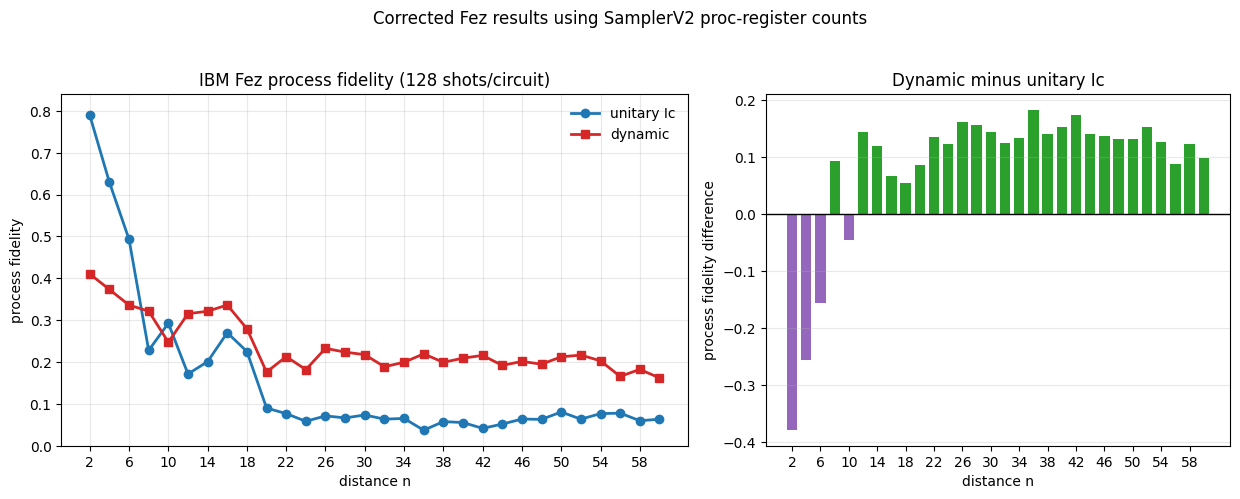

In [1]:
# Plot corrected IBM Fez process-fidelity results: dynamic vs unitary Ic.
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

fez_log_path = Path("log/ibm_fez_distance_sweep/ibm_fez_distance_sweep.jsonl")
records = []
for line in fez_log_path.read_text(encoding="utf-8").splitlines():
    if line.strip():
        records.append(json.loads(line))

active_shots = int(globals().get("IBM_FEZ_SWEEP_SHOTS", 128))

# Keep only the latest append-only record per (distance, circuit) for the active shot count.
# The corrected fidelity records have fidelity_schema_version=2 and read Sampler register "proc".
latest = {}
for record in records:
    if int(record.get("shots_per_circuit", -1)) != active_shots:
        continue
    if record.get("event") in {"submitted", "status", "completed"}:
        latest[(int(record.get("distance")), record.get("circuit"))] = record

rows = []
for record in latest.values():
    if record.get("event") != "completed":
        continue
    rows.append(
        {
            "distance": int(record["distance"]),
            "circuit": record["circuit"],
            "shots_per_circuit": int(record["shots_per_circuit"]),
            "process_fidelity": float(record["process_fidelity"]),
            "gate_fidelity": float(record["gate_fidelity"]),
        }
    )

fez_fidelity_df = pd.DataFrame(rows).sort_values(["distance", "circuit"])
fez_fidelity_comparison = fez_fidelity_df.pivot_table(
    index="distance",
    columns="circuit",
    values="process_fidelity",
    aggfunc="last",
).reset_index()
fez_fidelity_comparison["dynamic_minus_unitary_Ic"] = (
    fez_fidelity_comparison["dynamic"] - fez_fidelity_comparison["unitary Ic"]
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={"width_ratios": [1.35, 1.0]})
ax = axes[0]
ax.plot(fez_fidelity_comparison["distance"], fez_fidelity_comparison["unitary Ic"], marker="o", linewidth=2.0, label="unitary Ic", color="#1f77b4")
ax.plot(fez_fidelity_comparison["distance"], fez_fidelity_comparison["dynamic"], marker="s", linewidth=2.0, label="dynamic", color="#d62728")
ax.set_title(f"IBM Fez process fidelity ({active_shots} shots/circuit)")
ax.set_xlabel("distance n")
ax.set_ylabel("process fidelity")
ax.set_ylim(0, max(0.8, float(fez_fidelity_comparison[["dynamic", "unitary Ic"]].max().max()) + 0.05))
ax.set_xticks(fez_fidelity_comparison["distance"][::2])
ax.grid(True, alpha=0.28)
ax.legend(frameon=False)

ax = axes[1]
colors = ["#2ca02c" if value >= 0 else "#9467bd" for value in fez_fidelity_comparison["dynamic_minus_unitary_Ic"]]
ax.bar(fez_fidelity_comparison["distance"], fez_fidelity_comparison["dynamic_minus_unitary_Ic"], color=colors, width=1.45)
ax.axhline(0, color="black", linewidth=1.0)
ax.set_title("Dynamic minus unitary Ic")
ax.set_xlabel("distance n")
ax.set_ylabel("process fidelity difference")
ax.set_xticks(fez_fidelity_comparison["distance"][::2])
ax.grid(True, axis="y", alpha=0.28)

fig.suptitle("Corrected Fez results using SamplerV2 proc-register counts", y=1.03, fontsize=12)
fig.tight_layout()
plot_path = Path("log/ibm_fez_distance_sweep") / f"ibm_fez_process_fidelity_comparison_shots_{active_shots}.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
print(f"Saved plot to {plot_path}")
plt.show()
